In [ ]:
ufrom kaggle_secrets import UserSecretsClient
_secrets = UserSecretsClient()
import os
os.environ['KAGGLE_USERNAME'] = _secrets.get_secret('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = _secrets.get_secret('KAGGLE_KEY')

## Install Dependencies

In [ ]:
# ── Cell 0: Install Dependencies ──────────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(
    "torch", "torchaudio",
    "numpy", "pandas", "scikit-learn",
    "librosa", "soundfile",
    "tqdm", "matplotlib", "seaborn",
)
## Imports and Global Utilities
import os, sys, random, json, time, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import soundfile as sf
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    balanced_accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc as sk_auc
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ── General utilities ─────────────────────────────────────────────────────────
def to_numpy(t):
    return t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.array(t)

def flatten_dict(d, parent_key="", sep="/"):
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.update(flatten_dict(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items

## Logging

In [ ]:
import logging, sys
from datetime import datetime
from pathlib import Path

LOG_DIR = Path("/kaggle/working/logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

run_id   = datetime.now().strftime("%Y%m%d_%H%M%S")
log_file = LOG_DIR / f"run_{run_id}.log"          # ← fixed: was .logger.info

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger("mega_ia")

experiment_log = []

def log_result(exp_name: str, metrics: dict):
    entry = {"experiment": exp_name, "timestamp": run_id, **flatten_dict(metrics)}
    experiment_log.append(entry)
    logger.info(f"[{exp_name}] {metrics}")

def save_experiment_log(path: str = None):
    out = Path(path) if path else LOG_DIR / f"results_{run_id}.json"
    with open(out, "w") as f:
        json.dump(experiment_log, f, indent=2, default=str)
    logger.info(f"Experiment log saved → {out}")

logger.info(f"Logging initialised | run_id={run_id} | log={log_file}")

2026-05-11 04:30:00,759 | INFO | Logging initialised | run_id=20260511_043000 | log=/kaggle/working/logs/run_20260511_043000.log


## Paths and Configurattions

In [ ]:
## Paths and Configurattions
from pathlib import Path


VALPATH          = Path("/kaggle/input/datasets/aww4bahmad/dataseet/datasets/validation_dataset")
VAL_REAL_DIR     = VALPATH / "real"
VAL_FAKE_DIR     = VALPATH / "fake"
VAL_META_CSV     = Path("/kaggle/input/datasets/aww4bahmad/dataseet/datasets/validation_dataset/meta.csv")

LA_TEST_META        = Path("/kaggle/input/datasets/aww4bahmad/dataseet/datasets/la_test/meta.csv")
IN_THE_WILD_META    = Path("/kaggle/input/datasets/aww4bahmad/dataseet/datasets/in_the_wild_test/meta.csv")
DEEPFAKE_EVALS_META = Path("/kaggle/input/datasets/aww4bahmad/dataseet/datasets/Deepfake-Eval-2024/audio-metadata-publish.csv")

CKPT_DIR = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "baseline":   CKPT_DIR / "rawnet2_baseline.pth",
    "mega_ia_v1": CKPT_DIR / "rawnet2_mega_ia_v1.pth",
    "mega_ia_v2": CKPT_DIR / "rawnet2_mega_ia_v2.pth",
    "la_parent":  Path("/kaggle/input/models/aww4bahmad/rawnet/pytorch/default/1/best_model.pth"),
    "itw_parent": Path("/kaggle/input/models/aww4bahmad/rawnet/pytorch/default/1/best_auc.pth"),
}

SAMPLE_RATE  = 16000
MAX_DURATION = 4
MAX_SAMPLES  = SAMPLE_RATE * MAX_DURATION
BATCH_SIZE   = 32
NUM_WORKERS  = 4
NUM_EPOCHS   = 50
LR           = 1e-4
SEED         = 42

for p in [VALPATH, VAL_REAL_DIR, VAL_FAKE_DIR]:
    if not p.exists(): logger.warning(f'Path not found: {p}')
    else: logger.info(f'OK: {p}')

# ADD to the bottom of Cell 6 (Paths cell), after the path existence checks:
import shutil, subprocess

KAGGLE_DATASET_SLUG = 'aww4bahmad/mega-ia-checkpoints'

def push_checkpoints(label='checkpoint'):
    """Push CKPT_DIR contents to Kaggle dataset as a new version."""
    try:
        meta = {'title': 'mega-ia-checkpoints', 'id': KAGGLE_DATASET_SLUG,
                'licenses': [{'name': 'CC0-1.0'}]}
        with open(CKPT_DIR / 'dataset-metadata.json', 'w') as f:
            json.dump(meta, f)
        result = subprocess.run(
            ['kaggle', 'datasets', 'version', '-p', str(CKPT_DIR),
             '-m', label, '--dir-mode', 'skip'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            logger.info(f'✅ Checkpoints pushed → "{label}"')
        else:
            logger.warning(f'⚠️  Checkpoint push failed: {result.stderr.strip()}')
    except Exception as e:
        logger.warning(f'⚠️  push_checkpoints error: {e}')

push_checkpoints(label='connection-test')  # ← one-time verify, remove after confirmed working

2026-05-11 04:30:00,790 | INFO | OK: /kaggle/input/datasets/aww4bahmad/dataseet/datasets/validation_dataset
2026-05-11 04:30:00,796 | INFO | OK: /kaggle/input/datasets/aww4bahmad/dataseet/datasets/validation_dataset/real
2026-05-11 04:30:00,800 | INFO | OK: /kaggle/input/datasets/aww4bahmad/dataseet/datasets/validation_dataset/fake
2026-05-11 04:30:06,113 | INFO | ✅ Checkpoints pushed → "connection-test"


## Device Setup (Multi-GPU)


In [ ]:
import torch

N_GPUS = torch.cuda.device_count()

if N_GPUS >= 2:
    GPU0 = torch.device("cuda:0")
    GPU1 = torch.device("cuda:1")
    torch.backends.cudnn.benchmark    = True    # fastest conv kernel per shape
    torch.backends.cudnn.deterministic = False  # consistent: can't have both
    for i in range(N_GPUS):
        props = torch.cuda.get_device_properties(i)
        logger.info(f"CUDA:{i} — {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")
    logger.info("Multi-GPU mode: 2 independent GPUs confirmed.")
    MULTI_GPU = True
elif torch.cuda.is_available():
    GPU0 = GPU1 = torch.device("cuda")
    torch.backends.cudnn.benchmark    = True
    torch.backends.cudnn.deterministic = False
    logger.warning("Single-GPU mode — experiments will run sequentially on cuda:0.")
    MULTI_GPU = False
else:
    GPU0 = GPU1 = torch.device("cpu")
    logger.info("Device: CPU")
    MULTI_GPU = False

DEVICE  = GPU0   # alias kept for downstream compatibility
DEVICE2 = GPU1

# ── Per-GPU checkpoint directories ────────────────────────────────────────────
# Rule: GPU0 writes ONLY to gpu0/.  GPU1 writes ONLY to gpu1/.
# Both GPUs may READ from shared/ (feature caches, split metadata).
GPU0_CKPT_DIR = CKPT_DIR / "gpu0"
GPU1_CKPT_DIR = CKPT_DIR / "gpu1"
SHARED_DIR    = CKPT_DIR / "shared"   # DFE split cache, parent baselines, feature files

for d in [GPU0_CKPT_DIR, GPU1_CKPT_DIR, SHARED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Map device → its own checkpoint dir (used in experiment threads)
GPU_CKPT_MAP = {GPU0: GPU0_CKPT_DIR, GPU1: GPU1_CKPT_DIR}

logger.info(f"GPU0 checkpoint dir → {GPU0_CKPT_DIR}")
logger.info(f"GPU1 checkpoint dir → {GPU1_CKPT_DIR}")
logger.info(f"Shared dir          → {SHARED_DIR}")
logger.info(f"Active devices      → primary={GPU0}, secondary={GPU1}")

2026-05-11 04:30:06,428 | INFO | CUDA:0 — Tesla T4 | VRAM: 15.6 GB
2026-05-11 04:30:06,429 | INFO | CUDA:1 — Tesla T4 | VRAM: 15.6 GB
2026-05-11 04:30:06,429 | INFO | Multi-GPU mode: 2 independent GPUs confirmed.
2026-05-11 04:30:06,432 | INFO | GPU0 checkpoint dir → /kaggle/working/checkpoints/gpu0
2026-05-11 04:30:06,432 | INFO | GPU1 checkpoint dir → /kaggle/working/checkpoints/gpu1
2026-05-11 04:30:06,433 | INFO | Shared dir          → /kaggle/working/checkpoints/shared
2026-05-11 04:30:06,434 | INFO | Active devices      → primary=cuda:0, secondary=cuda:1


## RawNet2 Architecture

In [ ]:
## RawNet2 Architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import math
from torch.utils import data
from collections import OrderedDict
from torch.nn.parameter import Parameter
from torch.autograd import Variable
import pickle
import random


class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)


    def __init__(self, device,out_channels, kernel_size,in_channels=1,sample_rate=16000,
                 stride=1, padding=0, dilation=1, bias=False, groups=1,freq_scale='Mel'):

        super(SincConv,self).__init__()


        if in_channels != 1:

            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)

        self.out_channels = out_channels+1
        self.kernel_size = kernel_size
        self.sample_rate=sample_rate

        # Forcing the filters to be odd (i.e, perfectly symmetrics)
        if kernel_size%2==0:
            self.kernel_size=self.kernel_size+1

        self.device=device
        self.stride = stride
        self.padding = padding
        self.dilation = dilation

        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')


        # initialize filterbanks using Mel scale
        NFFT = 512
        f=int(self.sample_rate/2)*np.linspace(0,1,int(NFFT/2)+1)


        if freq_scale == 'Mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.freq=filbandwidthsf[:self.out_channels]

        elif freq_scale == 'Inverse-mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.mel=filbandwidthsf[:self.out_channels]
            self.freq=np.abs(np.flip(self.mel)-1) ## invert mel scale


        else:
            fmelmax=np.max(f)
            fmelmin=np.min(f)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            self.freq=filbandwidthsmel[:self.out_channels]

        self.hsupp=torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2+1)
        self.band_pass=torch.zeros(self.out_channels-1,self.kernel_size)



    def forward(self,x):
        for i in range(len(self.freq)-1):
            fmin=self.freq[i]
            fmax=self.freq[i+1]
            hHigh=(2*fmax/self.sample_rate)*np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow=(2*fmin/self.sample_rate)*np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal=hHigh-hLow

            self.band_pass[i,:]=Tensor(np.hamming(self.kernel_size))*Tensor(hideal)

        band_pass_filter=self.band_pass.to(self.device)

        self.filters = (band_pass_filter).view(self.out_channels-1, 1, self.kernel_size)

        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation,
                         bias=None, groups=1)



class Residual_block(nn.Module):
    def __init__(self, nb_filts, first = False):
        super(Residual_block, self).__init__()
        self.first = first

        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features = nb_filts[0])

        self.lrelu = nn.LeakyReLU(negative_slope=0.3)

        self.conv1 = nn.Conv1d(in_channels = nb_filts[0],
			out_channels = nb_filts[1],
			kernel_size = 3,
			padding = 1,
			stride = 1)

        self.bn2 = nn.BatchNorm1d(num_features = nb_filts[1])
        self.conv2 = nn.Conv1d(in_channels = nb_filts[1],
			out_channels = nb_filts[1],
			padding = 1,
			kernel_size = 3,
			stride = 1)

        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv1d(in_channels = nb_filts[0],
				out_channels = nb_filts[1],
				padding = 0,
				kernel_size = 1,
				stride = 1)

        else:
            self.downsample = False
        self.mp = nn.MaxPool1d(3)

    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.lrelu(out)
        else:
            out = x

        out = self.conv1(out)
        out = self.bn2(out)
        out = self.lrelu(out)
        out = self.conv2(out)

        if self.downsample:
            identity = self.conv_downsample(identity)

        out += identity
        out = self.mp(out)
        return out





class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()


        self.device=device

        self.Sinc_conv=SincConv(device=self.device,
			out_channels = d_args['filts'][0],
			kernel_size = d_args['first_conv'],
                        in_channels = d_args['in_channels'],freq_scale='Mel'
        )

        self.first_bn = nn.BatchNorm1d(num_features = d_args['filts'][0])
        self.selu = nn.SELU(inplace=True)
        self.block0 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1], first = True))
        self.block1 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1]))
        self.block2 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        # Compute [out, out] config for blocks 3-5 WITHOUT mutating d_args in-place.
        # The original code did `d_args['filts'][2][0] = d_args['filts'][2][1]` which
        # permanently corrupted d_args for every subsequent RawNet() call in the session.
        filts2_after = [d_args['filts'][2][1], d_args['filts'][2][1]]
        self.block3 = nn.Sequential(Residual_block(nb_filts = filts2_after))
        self.block4 = nn.Sequential(Residual_block(nb_filts = filts2_after))
        self.block5 = nn.Sequential(Residual_block(nb_filts = filts2_after))
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.fc_attention0 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention1 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention2 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention3 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention4 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention5 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features = d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size = d_args['filts'][2][-1],
			hidden_size = d_args['gru_node'],
			num_layers = d_args['nb_gru_layer'],
			batch_first = True)


        self.fc1_gru = nn.Linear(in_features = d_args['gru_node'],
			out_features = d_args['nb_fc_node'])

        self.fc2_gru = nn.Linear(in_features = d_args['nb_fc_node'],
			out_features = d_args['nb_classes'],bias=True)


        self.sig = nn.Sigmoid()


    def forward(self, x, y = None,is_test=False):


        nb_samp = x.shape[0]
        len_seq = x.shape[1]
        x=x.view(nb_samp,1,len_seq)

        x = self.Sinc_conv(x)    # Fixed sinc filters convolution
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.first_bn(x)
        x = self.selu(x)

        x0 = self.block0(x)
        y0 = self.avgpool(x0).view(x0.size(0), -1) # torch.Size([batch, filter])
        y0 = self.fc_attention0(y0)
        y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)


        x1 = self.block1(x)
        y1 = self.avgpool(x1).view(x1.size(0), -1) # torch.Size([batch, filter])
        y1 = self.fc_attention1(y1)
        y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x1 * y1 + y1 # (batch, filter, time) x (batch, filter, 1)

        x2 = self.block2(x)
        y2 = self.avgpool(x2).view(x2.size(0), -1) # torch.Size([batch, filter])
        y2 = self.fc_attention2(y2)
        y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x2 * y2 + y2 # (batch, filter, time) x (batch, filter, 1)

        x3 = self.block3(x)
        y3 = self.avgpool(x3).view(x3.size(0), -1) # torch.Size([batch, filter])
        y3 = self.fc_attention3(y3)
        y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x3 * y3 + y3 # (batch, filter, time) x (batch, filter, 1)

        x4 = self.block4(x)
        y4 = self.avgpool(x4).view(x4.size(0), -1) # torch.Size([batch, filter])
        y4 = self.fc_attention4(y4)
        y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x4 * y4 + y4 # (batch, filter, time) x (batch, filter, 1)

        x5 = self.block5(x)
        y5 = self.avgpool(x5).view(x5.size(0), -1) # torch.Size([batch, filter])
        y5 = self.fc_attention5(y5)
        y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x5 * y5 + y5 # (batch, filter, time) x (batch, filter, 1)

        x = self.bn_before_gru(x)
        x = self.selu(x)
        x = x.permute(0, 2, 1)     #(batch, filt, time) >> (batch, time, filt)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:,-1,:]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)

        if not is_test:
            output = x
            return output

        else:
            output=F.softmax(x,dim=1)
            return output




    def _make_attention_fc(self, in_features, l_out_features):

        l_fc = []

        l_fc.append(nn.Linear(in_features = in_features,
			        out_features = l_out_features))



        return nn.Sequential(*l_fc)


    def _make_layer(self, nb_blocks, nb_filts, first = False):
        layers = []
        #def __init__(self, nb_filts, first = False):
        for i in range(nb_blocks):
            first = first if i == 0 else False
            layers.append(Residual_block(nb_filts = nb_filts,
				first = first))
            if i == 0: nb_filts[0] = nb_filts[1]

        return nn.Sequential(*layers)

    def summary(self, input_size, batch_size=-1, device="cuda", print_fn = None):
        if print_fn == None: printfn = print
        model = self

        def register_hook(module):
            def hook(module, input, output):
                class_name = str(module.__class__).split(".")[-1].split("'")[0]
                module_idx = len(summary)

                m_key = "%s-%i" % (class_name, module_idx + 1)
                summary[m_key] = OrderedDict()
                summary[m_key]["input_shape"] = list(input[0].size())
                summary[m_key]["input_shape"][0] = batch_size
                if isinstance(output, (list, tuple)):
                    summary[m_key]["output_shape"] = [
						[-1] + list(o.size())[1:] for o in output
					]
                else:
                    summary[m_key]["output_shape"] = list(output.size())
                    if len(summary[m_key]["output_shape"]) != 0:
                        summary[m_key]["output_shape"][0] = batch_size

                params = 0
                if hasattr(module, "weight") and hasattr(module.weight, "size"):
                    params += torch.prod(torch.LongTensor(list(module.weight.size())))
                    summary[m_key]["trainable"] = module.weight.requires_grad
                if hasattr(module, "bias") and hasattr(module.bias, "size"):
                    params += torch.prod(torch.LongTensor(list(module.bias.size())))
                summary[m_key]["nb_params"] = params

            if (
				not isinstance(module, nn.Sequential)
				and not isinstance(module, nn.ModuleList)
				and not (module == model)
			):
                hooks.append(module.register_forward_hook(hook))

        device = device.lower()
        assert device in [
			"cuda",
			"cpu",
		], "Input device is not valid, please specify 'cuda' or 'cpu'"

        if device == "cuda" and torch.cuda.is_available():
            dtype = torch.cuda.FloatTensor
        else:
            dtype = torch.FloatTensor
        if isinstance(input_size, tuple):
            input_size = [input_size]
        x = [torch.rand(2, *in_size).type(dtype) for in_size in input_size]
        summary = OrderedDict()
        hooks = []
        model.apply(register_hook)
        model(*x)
        for h in hooks:
            h.remove()

## Dataset Classes


In [ ]:
## Dataset Classes
import warnings
from torch.utils.data import Dataset

def pad_random(x: np.ndarray, max_len: int = 64600) -> np.ndarray:
    x_len = x.shape[0]
    if x_len > max_len:
        stt = np.random.randint(x_len - max_len)
        return x[stt:stt + max_len]
    return np.tile(x, (int(max_len / x_len) + 1))[:max_len]

class ValidationDataset(Dataset):
    """
    Local validation dataset.
    CSV columns: filename, label ('real' | 'fake')
    Files are in root_dir/real/ and root_dir/fake/ subdirs.
    """
    TARGET_SR = 16000

    def __init__(self, root_dir: str):
        self.root_dir = root_dir
        df = pd.read_csv(os.path.join(root_dir, 'meta.csv'))
        self.df = df.reset_index(drop=True)
        self.n_fake = int((self.df['label'] == 'fake').sum())
        self.n_real = int((self.df['label'] == 'real').sum())

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        subdir = row['label']   # 'real' or 'fake' — matches the subdir name exactly
        path  = os.path.join(self.root_dir, subdir, row['filename'])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
        label = 1 if row['label'] == 'real' else 0
        return torch.FloatTensor(pad_random(x)), label


logger.info('ValidationDataset patched (real/fake subdirs).')

class LATestDataset(Dataset):
    """
    ASVspoof LA test set.
    CSV columns: Filename, Ground Truth
    Ground Truth: 'Real' | 'Fake'
    """
    TARGET_SR = 16000

    def __init__(self, meta_csv: str):
        self.root_dir = os.path.dirname(meta_csv)
        df = pd.read_csv(meta_csv)
        self.df = df.reset_index(drop=True)
        self.n_real = int((self.df['Ground Truth'] == 'Real').sum())
        self.n_fake = int((self.df['Ground Truth'] == 'Fake').sum())

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.root_dir, str(row['Filename']))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
        label = 1 if row['Ground Truth'] == 'Real' else 0
        return torch.FloatTensor(pad_random(x)), label


class InTheWildDataset(Dataset):
    """
    In-the-Wild test set.
    CSV columns: file, speaker, label
    label: 'bona-fide' | 'spoof'
    """
    TARGET_SR = 16000

    def __init__(self, meta_csv: str):
        self.root_dir = os.path.dirname(meta_csv)
        df = pd.read_csv(meta_csv)
        self.df = df.reset_index(drop=True)
        self.n_real = int((self.df['label'] == 'bona-fide').sum())
        self.n_fake = int((self.df['label'] == 'spoof').sum())

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.root_dir, str(row['file']))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
        label = 1 if row['label'] == 'bona-fide' else 0
        return torch.FloatTensor(pad_random(x)), label


class DeepfakeEvalsDataset(Dataset):
    """
    Deepfake-Evals-2024.
    CSV columns: Filename, Date, Ground Truth, Public Comments, Finetuning Set
    Ground Truth: 'Real' | 'Fake'
    Audio files are under root_dir/audio-data/<Filename>
    """
    TARGET_SR = 16000
    AUDIO_SUBDIR = "audio-data"

    def __init__(self, root_dir: str, cache_dir: str = None, indices=None):
        self.root_dir  = root_dir
        self.audio_dir = os.path.join(root_dir, self.AUDIO_SUBDIR)
        df = pd.read_csv(os.path.join(root_dir, 'audio-metadata-publish.csv'))
        df = df[df['Filename'].notna()].copy()
        df['Filename'] = df['Filename'].astype(str).str.strip()

        cache_path = os.path.join(cache_dir, 'deepfake_valid_indices.json') if cache_dir else None

        if cache_path and os.path.exists(cache_path):
            with open(cache_path) as f:
                cached = json.load(f)
            good = cached['good_indices']
            logger.info(f'Loaded cached file list ({len(good)} valid, {cached.get("skip_count",0)} skipped).')
        else:
            logger.info('Pre-flighting Deepfake-Evals files (runs once, then cached)...')
            good, skip = [], []
            total = len(df)
            for pos, (i, row) in enumerate(df.iterrows()):
                if pos % 100 == 0:
                    logger.info(f'  Pre-flight: {pos}/{total}...')
                path = os.path.join(self.audio_dir, row['Filename'])
                if not os.path.isfile(path):
                    skip.append(row['Filename']); continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        librosa.load(path, sr=None, mono=True, duration=0.1)
                    good.append(i)
                except Exception:
                    skip.append(row['Filename'])
            if cache_path:
                with open(cache_path, 'w') as f:
                    json.dump({'good_indices': good, 'skip_count': len(skip)}, f)
                logger.info(f'Valid file list cached → {cache_path}')

        self.df = df.loc[good].reset_index(drop=True)
        if indices is not None:
            self.df = self.df.loc[indices].reset_index(drop=True)

        self.n_real = int((self.df['Ground Truth'] == 'Real').sum())
        self.n_fake = int((self.df['Ground Truth'] == 'Fake').sum())

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.audio_dir, str(row['Filename']))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
        label = 1 if row['Ground Truth'] == 'Real' else 0
        return torch.FloatTensor(pad_random(x)), label


logger.info('Dataset classes defined (all using librosa).')


def split_deepfake_evals(root_dir: str, cache_dir: str,
                         val_frac: float = 0.15,
                         seed: int = SEED):
    """
    Return three disjoint DeepfakeEvalsDataset instances:
        full_ds   — 100% (all valid files)
        val_ds    — 15%  balanced: equal Real/Fake counts  (7.5% each)
        test_ds   — 85%  remainder (all files not in val)

    Constraint: val set is balanced — Real count == Fake count.
    The smaller of (target_real, target_fake) determines val size per class.
    """
    rng = np.random.default_rng(seed)

    # Build full dataset first to get the validated df
    full_ds = DeepfakeEvalsDataset(root_dir, cache_dir=cache_dir)
    df = full_ds.df.copy()

    real_idx = df.index[df['Ground Truth'] == 'Real'].tolist()
    fake_idx = df.index[df['Ground Truth'] == 'Fake'].tolist()

    n_total      = len(df)
    n_val_target = int(n_total * val_frac)          # 15% of total
    n_per_class  = n_val_target // 2                # equal split
    # Clamp to available counts
    n_per_class  = min(n_per_class, len(real_idx), len(fake_idx))

    rng.shuffle(real_idx := np.array(real_idx))
    rng.shuffle(fake_idx := np.array(fake_idx))

    val_real = real_idx[:n_per_class].tolist()
    val_fake = fake_idx[:n_per_class].tolist()
    val_idx  = val_real + val_fake

    val_idx_set  = set(val_idx)
    test_idx     = [i for i in df.index.tolist() if i not in val_idx_set]

    val_ds  = DeepfakeEvalsDataset(root_dir, cache_dir=cache_dir, indices=val_idx)
    test_ds = DeepfakeEvalsDataset(root_dir, cache_dir=cache_dir, indices=test_idx)

    logger.info(f'DFE full : {len(full_ds):,}  ({full_ds.n_real:,} real / {full_ds.n_fake:,} fake)')
    logger.info(f'DFE val  : {len(val_ds):,}  ({val_ds.n_real:,} real / {val_ds.n_fake:,} fake)  [{len(val_ds)/len(full_ds)*100:.1f}%]')
    logger.info(f'DFE test : {len(test_ds):,}  ({test_ds.n_real:,} real / {test_ds.n_fake:,} fake)  [{len(test_ds)/len(full_ds)*100:.1f}%]')
    assert len(val_idx_set & set(test_idx)) == 0, 'Disjoint constraint violated!'
    assert val_ds.n_real == val_ds.n_fake,         'Val balance constraint violated!'

    return full_ds, val_ds, test_ds


logger.info('Dataset classes defined.')

2026-05-11 04:30:06,509 | INFO | ValidationDataset patched (real/fake subdirs).
2026-05-11 04:30:06,513 | INFO | Dataset classes defined (all using librosa).
2026-05-11 04:30:06,515 | INFO | Dataset classes defined.


## Load Datasets (Full — No Subsampling)

In [ ]:
from torch.utils.data import DataLoader

logger.info("╔" + "═" * 68 + "╗")
logger.info("║  PRE-EXPERIMENT SETUP — main thread only                        ║")
logger.info("║  GPU0 and GPU1 are IDLE until the feature-extraction cell        ║")
logger.info("║  completes. Parallelism starts when experiments begin.           ║")
logger.info("╚" + "═" * 68 + "╝")

logger.info("Loading validation dataset...")
val_ds = ValidationDataset(str(VALPATH))
logger.info(f"  Val:           {len(val_ds):,} samples  ({val_ds.n_real:,} real / {val_ds.n_fake:,} fake)")

logger.info("Loading LA test set...")
la_ds = LATestDataset(str(LA_TEST_META))
logger.info(f"  LA test:       {len(la_ds):,} samples  ({la_ds.n_real:,} real / {la_ds.n_fake:,} fake)")

logger.info("Loading In-the-Wild test set...")
itw_ds = InTheWildDataset(str(IN_THE_WILD_META))
logger.info(f"  In-the-Wild:   {len(itw_ds):,} samples  ({itw_ds.n_real:,} real / {itw_ds.n_fake:,} fake)")

logger.info("Loading Deepfake-Evals-2024 (full + splits)...")
dfe_root = str(DEEPFAKE_EVALS_META.parent)
dfe_full_ds, dfe_val_ds, dfe_test_ds = split_deepfake_evals(
    root_dir=dfe_root, cache_dir=str(SHARED_DIR), val_frac=0.15, seed=SEED
)

_pin = True
_nw  = NUM_WORKERS

# These loaders are READ-ONLY during experiments.
# Each GPU thread creates its OWN fitness loader (stateful) internally.
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
la_loader       = DataLoader(la_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
itw_loader      = DataLoader(itw_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
dfe_full_loader = DataLoader(dfe_full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
dfe_val_loader  = DataLoader(dfe_val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
dfe_test_loader = DataLoader(dfe_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)

for name, ldr in [("val", val_loader), ("la", la_loader), ("itw", itw_loader),
                  ("dfe_full", dfe_full_loader), ("dfe_val", dfe_val_loader),
                  ("dfe_test", dfe_test_loader)]:
    logger.info(f"  {name:>10}: {len(ldr):,} batches")

# Smoke-test
logger.info("Smoke-testing all loaders...")
for name, ldr in [("val", val_loader), ("la", la_loader), ("itw", itw_loader),
                  ("dfe_full", dfe_full_loader), ("dfe_val", dfe_val_loader),
                  ("dfe_test", dfe_test_loader)]:
    xb, yb = next(iter(ldr))
    logger.info(f"  {name:>10} batch: {tuple(xb.shape)}  labels={yb[:4].tolist()}")
    del xb, yb

logger.info("✅ All loaders confirmed. Datasets ready (pre-experiment).")

2026-05-11 04:30:06,533 | INFO | ╔════════════════════════════════════════════════════════════════════╗
2026-05-11 04:30:06,534 | INFO | ║  PRE-EXPERIMENT SETUP — main thread only                        ║
2026-05-11 04:30:06,535 | INFO | ║  GPU0 and GPU1 are IDLE until the feature-extraction cell        ║
2026-05-11 04:30:06,537 | INFO | ║  completes. Parallelism starts when experiments begin.           ║
2026-05-11 04:30:06,537 | INFO | ╚════════════════════════════════════════════════════════════════════╝
2026-05-11 04:30:06,538 | INFO | Loading validation dataset...
2026-05-11 04:30:06,568 | INFO |   Val:           102 samples  (51 real / 51 fake)
2026-05-11 04:30:06,569 | INFO | Loading LA test set...
2026-05-11 04:30:06,592 | INFO |   LA test:       1,000 samples  (500 real / 500 fake)
2026-05-11 04:30:06,593 | INFO | Loading In-the-Wild test set...
2026-05-11 04:30:06,618 | INFO |   In-the-Wild:   3,176 samples  (1,588 real / 1,588 fake)
2026-05-11 04:30:06,619 | INFO | Loading D

[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.


2026-05-11 04:31:16,164 | INFO |     dfe_full batch: (32, 64600)  labels=[1, 1, 0, 1]
2026-05-11 04:31:58,042 | INFO |      dfe_val batch: (32, 64600)  labels=[1, 1, 1, 1]


[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.


2026-05-11 04:32:29,315 | INFO |     dfe_test batch: (32, 64600)  labels=[1, 1, 0, 1]
2026-05-11 04:32:29,317 | INFO | ✅ All loaders confirmed. Datasets ready (pre-experiment).


## Load Parent Checkpoints


In [ ]:
logger.info("─" * 70)
logger.info("PRE-EXPERIMENT: Loading parent checkpoints on GPU0...")
logger.info("─" * 70)

d_args = {
    'filts'       : [128, [128, 128], [128, 512]],
    'first_conv'  : 1024,
    'in_channels' : 1,
    'gru_node'    : 1024,
    'nb_gru_layer': 3,
    'nb_fc_node'  : 1024,
    'nb_classes'  : 2,
}

def load_parent(path, label):
    ckpt = torch.load(path, map_location=GPU0, weights_only=False)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        sd = ckpt['model_state_dict']
        logger.info(f"  {label}: full checkpoint, epoch={ckpt.get('epoch', '?')}")
    else:
        sd = ckpt
        logger.info(f"  {label}: weights-only checkpoint")
    logger.info(f"  {label}: {len(sd)} keys")
    return sd

p1_state = load_parent(MODEL_PATHS['la_parent'],  'LA parent  (p1)')
p2_state = load_parent(MODEL_PATHS['itw_parent'], 'ITW parent (p2)')

assert set(p1_state.keys()) == set(p2_state.keys()), "Parent key mismatch!"

_probe = RawNet(d_args, GPU0).to(GPU0)
_model_keys = set(_probe.state_dict().keys())
del _probe

missing = _model_keys - set(p1_state.keys())
extra   = set(p1_state.keys()) - _model_keys
if missing or extra:
    if missing: logger.warning(f"Missing in checkpoint: {missing}")
    if extra:   logger.warning(f"Extra in checkpoint  : {extra}")
    raise RuntimeError("Parent keys do not match RawNet. Inspect above.")

torch.cuda.empty_cache()
logger.info("✅ Both parents loaded and verified on GPU0.")

2026-05-11 04:32:29,327 | INFO | ──────────────────────────────────────────────────────────────────────
2026-05-11 04:32:29,329 | INFO | PRE-EXPERIMENT: Loading parent checkpoints on GPU0...
2026-05-11 04:32:29,330 | INFO | ──────────────────────────────────────────────────────────────────────
2026-05-11 04:32:32,323 | INFO |   LA parent  (p1): full checkpoint, epoch=50
2026-05-11 04:32:32,324 | INFO |   LA parent  (p1): 119 keys
2026-05-11 04:32:34,754 | INFO |   ITW parent (p2): full checkpoint, epoch=59
2026-05-11 04:32:34,755 | INFO |   ITW parent (p2): 119 keys
2026-05-11 04:32:35,123 | INFO | ✅ Both parents loaded and verified on GPU0.


## Core Utilities: Feature Extraction, CKA, Metrics


In [ ]:
# Core Utilities – GPU0/GPU1 FULLY ISOLATED
# Rule: GPU0 threads call _gpu0() only. GPU1 threads call _gpu1() only.
# full_metrics() is pure-CPU/NumPy – ONLY shared function allowed.

def full_metrics(labels, preds, scores):
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
    return {
        'accuracy'  : float(accuracy_score(labels, preds)),
        'auc'       : float(roc_auc_score(labels, scores)),
        'bal_acc'   : float(balanced_accuracy_score(labels, preds)),
        'precision' : float(precision_score(labels, preds, zero_division=0)),
        'recall'    : float(recall_score(labels, preds, zero_division=0)),
        'f1'        : float(f1_score(labels, preds, zero_division=0)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'confusion_matrix': cm.tolist(),
    }


# ─────────────────────────── GPU0 EXCLUSIVE ───────────────────────────────────

def compute_linear_cka_gpu0(x, y, device=None):
    dev = device if device is not None else GPU0
    x = x.to(dev).float(); y = y.to(dev).float()
    x = x - x.mean(0);     y = y - y.mean(0)
    num   = torch.norm(torch.matmul(x.t(), y)) ** 2
    denom = torch.norm(torch.matmul(x.t(), x)) * torch.norm(torch.matmul(y.t(), y)) + 1e-8
    r = (num / denom).item(); del x, y; return r

def extract_reference_features_gpu0(model, loader, device):
    model.eval(); fe, fm, ff = [], [], []
    def h_e(m, i, o): fe.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_m(m, i, o): fm.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_g(m, i, o): seq, _ = o; ff.append(seq[:, -1, :].detach().cpu())
    hooks = [model.block1.register_forward_hook(h_e),
              model.block3.register_forward_hook(h_m),
              model.gru.register_forward_hook(h_g)]
    with torch.no_grad():
        for x, _ in tqdm(loader, desc='  [GPU0] Extracting P1 feats', leave=False):
            model(x.to(device), is_test=True)
    for h in hooks: h.remove()
    return {'early': torch.cat(fe), 'mid': torch.cat(fm), 'final': torch.cat(ff)}

def evaluate_candidate_gpu0(model, loader, device, p1_feats, config):
    model.eval(); all_scores, all_labels, cf_e, cf_m, cf_f = [], [], [], [], []
    def h_e(m, i, o): cf_e.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_m(m, i, o): cf_m.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_g(m, i, o): seq, _ = o; cf_f.append(seq[:, -1, :].detach().cpu())
    hooks = [model.block1.register_forward_hook(h_e),
              model.block3.register_forward_hook(h_m),
              model.gru.register_forward_hook(h_g)]
    _t_inf = time.time()
    logger.info(f'[cuda:0]   >> inference loop start (batches={len(loader)})')
    with torch.no_grad():
        for _bi, (x, y) in enumerate(tqdm(loader, desc=f'[cuda:0] eval', leave=False)):
            if _bi == 0:
                logger.info(f'[cuda:0]   >> first batch received ({time.time()-_t_inf:.1f}s)')
            out = model(x.to(device), is_test=True)
            all_scores.append(out[:, 1].cpu().numpy()); all_labels.append(y.numpy())
    logger.info(f'[cuda:0]   >> inference done ({time.time()-_t_inf:.1f}s)')
    for h in hooks: h.remove()
    _t_cka = time.time()
    logger.info(f'[cuda:0]   >> CKA start')
    scores = np.concatenate(all_scores); labels = np.concatenate(all_labels)
    preds  = (scores > 0.5).astype(int)
    feat_e = torch.cat(cf_e); feat_m = torch.cat(cf_m); feat_f = torch.cat(cf_f)
    met = full_metrics(labels, preds, scores)
    met['scores'] = scores.tolist(); met['labels'] = labels.tolist()
    p = scores.clip(1e-8, 1 - 1e-8)
    met['confidence'] = float(np.mean(p**2 + (1-p)**2))
    p_mat = np.stack([1-p, p], axis=1)
    met['entropy'] = float(-np.mean(np.sum(p_mat * np.log2(p_mat), axis=1)))
    cka_mode = config.get('cka_mode', 'final')
    if cka_mode == 'multilayer':
        cka_e = compute_linear_cka_gpu0(feat_e, p1_feats['early'], device=device)
        cka_m = compute_linear_cka_gpu0(feat_m, p1_feats['mid'],   device=device)
        cka_f = compute_linear_cka_gpu0(feat_f, p1_feats['final'], device=device)
        cka_score = (cka_e + cka_m + cka_f) / 3.0
        met['cka_early'] = float(cka_e); met['cka_mid'] = float(cka_m); met['cka_final'] = float(cka_f)
    else:
        cka_score = compute_linear_cka_gpu0(feat_f, p1_feats['final'], device=device)
    met['cka'] = float(cka_score)
    logger.info(f'[cuda:0]   >> CKA done ({time.time()-_t_cka:.1f}s)')
    ft_type = config.get('fitness_type', 'accuracy')
    base = {'accuracy': met['accuracy'], 'auc': met['auc'],
            'balanced': met['bal_acc'], 'auc_f1': 0.6*met['auc']+0.4*met['f1']}[ft_type]
    pm = config.get('penalty_mode', 'entropy')
    fitness = (base - config['lambda1']*cka_score + config['lambda2']*met['confidence']
               if pm == 'confidence' else
               base - config['lambda1']*cka_score - config['lambda2']*met['entropy'])
    met['fitness'] = float(fitness); return met, float(fitness)

def save_exp_results_gpu0(ckpt_dir, exp_id, bvm, history, best_genome):
    out = {'exp_id': exp_id,
           'best_val_metrics': {k:v for k,v in bvm.items() if k not in ('scores','labels')},
           'history': history,
           'best_genome': best_genome.tolist() if hasattr(best_genome,'tolist') else best_genome}
    p = os.path.join(ckpt_dir, f'{exp_id}_results.json')
    tmp = p + '.tmp'
    with open(tmp,'w') as f: json.dump(out,f,indent=2)
    os.replace(tmp, p)
    logger.info(f'[GPU0] Saved → {p}')

def load_exp_results_gpu0(ckpt_dir, exp_id):
    p = os.path.join(ckpt_dir, f'{exp_id}_results.json')
    if not os.path.exists(p): return None
    try:
        with open(p) as f: return json.load(f)
    except Exception:
        logger.warning(f'[GPU0] Corrupt results file for {exp_id} — will re-run')
        return None

def save_test_results_gpu0(ckpt_dir, exp_id, ds_key, tm):
    p = os.path.join(ckpt_dir, f'{exp_id}_test_{ds_key}.json')
    with open(p,'w') as f: json.dump({k:v for k,v in tm.items() if k not in ('scores','labels')},f,indent=2)

def load_test_results_gpu0(ckpt_dir, exp_id, ds_key):
    p = os.path.join(ckpt_dir, f'{exp_id}_test_{ds_key}.json')
    if not os.path.exists(p): return None
    with open(p) as f: return json.load(f)


# ─────────────────────────── GPU1 EXCLUSIVE ───────────────────────────────────

def compute_linear_cka_gpu1(x, y, device=None):
    dev = device if device is not None else GPU1
    x = x.to(dev).float(); y = y.to(dev).float()
    x = x - x.mean(0);     y = y - y.mean(0)
    num   = torch.norm(torch.matmul(x.t(), y)) ** 2
    denom = torch.norm(torch.matmul(x.t(), x)) * torch.norm(torch.matmul(y.t(), y)) + 1e-8
    r = (num / denom).item(); del x, y; return r

def extract_reference_features_gpu1(model, loader, device):
    model.eval(); fe, fm, ff = [], [], []
    def h_e(m, i, o): fe.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_m(m, i, o): fm.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_g(m, i, o): seq, _ = o; ff.append(seq[:, -1, :].detach().cpu())
    hooks = [model.block1.register_forward_hook(h_e),
              model.block3.register_forward_hook(h_m),
              model.gru.register_forward_hook(h_g)]
    with torch.no_grad():
        for x, _ in tqdm(loader, desc='  [GPU1] Extracting P1 feats', leave=False):
            model(x.to(device), is_test=True)
    for h in hooks: h.remove()
    return {'early': torch.cat(fe), 'mid': torch.cat(fm), 'final': torch.cat(ff)}

def evaluate_candidate_gpu1(model, loader, device, p1_feats, config):
    model.eval(); all_scores, all_labels, cf_e, cf_m, cf_f = [], [], [], [], []
    def h_e(m, i, o): cf_e.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_m(m, i, o): cf_m.append(F.adaptive_avg_pool1d(o.detach().cpu(), 1).squeeze(-1))
    def h_g(m, i, o): seq, _ = o; cf_f.append(seq[:, -1, :].detach().cpu())
    hooks = [model.block1.register_forward_hook(h_e),
              model.block3.register_forward_hook(h_m),
              model.gru.register_forward_hook(h_g)]
    _t_inf = time.time()
    logger.info(f'[cuda:1]   >> inference loop start (batches={len(loader)})')
    with torch.no_grad():
        for _bi, (x, y) in enumerate(tqdm(loader, desc=f'[cuda:1] eval', leave=False)):
            if _bi == 0:
                logger.info(f'[cuda:1]   >> first batch received ({time.time()-_t_inf:.1f}s)')
            out = model(x.to(device), is_test=True)
            all_scores.append(out[:, 1].cpu().numpy()); all_labels.append(y.numpy())
    logger.info(f'[cuda:1]   >> inference done ({time.time()-_t_inf:.1f}s)')
    for h in hooks: h.remove()
    _t_cka = time.time()
    logger.info(f'[cuda:1]   >> CKA start')
    scores = np.concatenate(all_scores); labels = np.concatenate(all_labels)
    if not np.all(np.isfinite(scores)):
        raise ValueError(f'Model produced non-finite scores (NaN/inf count={np.sum(~np.isfinite(scores))})')
    preds  = (scores > 0.5).astype(int)
    feat_e = torch.cat(cf_e); feat_m = torch.cat(cf_m); feat_f = torch.cat(cf_f)
    met = full_metrics(labels, preds, scores)
    met['scores'] = scores.tolist(); met['labels'] = labels.tolist()
    p = scores.clip(1e-8, 1 - 1e-8)
    met['confidence'] = float(np.mean(p**2 + (1-p)**2))
    p_mat = np.stack([1-p, p], axis=1)
    met['entropy'] = float(-np.mean(np.sum(p_mat * np.log2(p_mat), axis=1)))
    cka_mode = config.get('cka_mode', 'final')
    if cka_mode == 'multilayer':
        cka_e = compute_linear_cka_gpu1(feat_e, p1_feats['early'], device=device)
        cka_m = compute_linear_cka_gpu1(feat_m, p1_feats['mid'],   device=device)
        cka_f = compute_linear_cka_gpu1(feat_f, p1_feats['final'], device=device)
        cka_score = (cka_e + cka_m + cka_f) / 3.0
        met['cka_early'] = float(cka_e); met['cka_mid'] = float(cka_m); met['cka_final'] = float(cka_f)
    else:
        cka_score = compute_linear_cka_gpu1(feat_f, p1_feats['final'], device=device)
    met['cka'] = float(cka_score)
    logger.info(f'[cuda:1]   >> CKA done ({time.time()-_t_cka:.1f}s)')
    ft_type = config.get('fitness_type', 'accuracy')
    base = {'accuracy': met['accuracy'], 'auc': met['auc'],
            'balanced': met['bal_acc'], 'auc_f1': 0.6*met['auc']+0.4*met['f1']}[ft_type]
    pm = config.get('penalty_mode', 'entropy')
    fitness = (base - config['lambda1']*cka_score + config['lambda2']*met['confidence']
               if pm == 'confidence' else
               base - config['lambda1']*cka_score - config['lambda2']*met['entropy'])
    met['fitness'] = float(fitness); return met, float(fitness)

def save_exp_results_gpu1(ckpt_dir, exp_id, bvm, history, best_genome):
    out = {'exp_id': exp_id,
           'best_val_metrics': {k:v for k,v in bvm.items() if k not in ('scores','labels')},
           'history': history,
           'best_genome': best_genome.tolist() if hasattr(best_genome,'tolist') else best_genome}
    p = os.path.join(ckpt_dir, f'{exp_id}_results.json')
    tmp = p + '.tmp'
    with open(tmp,'w') as f: json.dump(out,f,indent=2)
    os.replace(tmp, p)
    logger.info(f'[GPU1] Saved → {p}')

def load_exp_results_gpu1(ckpt_dir, exp_id):
    p = os.path.join(ckpt_dir, f'{exp_id}_results.json')
    if not os.path.exists(p): return None
    try:
        with open(p) as f: return json.load(f)
    except Exception:
        logger.warning(f'[GPU1] Corrupt results file for {exp_id} — will re-run')
        return None

def save_test_results_gpu1(ckpt_dir, exp_id, ds_key, tm):
    p = os.path.join(ckpt_dir, f'{exp_id}_test_{ds_key}.json')
    with open(p,'w') as f: json.dump({k:v for k,v in tm.items() if k not in ('scores','labels')},f,indent=2)

def load_test_results_gpu1(ckpt_dir, exp_id, ds_key):
    p = os.path.join(ckpt_dir, f'{exp_id}_test_{ds_key}.json')
    if not os.path.exists(p): return None
    with open(p) as f: return json.load(f)


logger.info('Core utilities defined (GPU0 / GPU1 fully isolated).')


2026-05-11 04:32:35,177 | INFO | Core utilities defined (GPU0 / GPU1 fully isolated).


## MeGA-IA Evolutionary Engine (Multi-GPU)


In [ ]:
import concurrent.futures, traceback

def _make_engine_gpu0():
    """Returns evaluate_genome_on_device_gpu0 and run_mega_ia_gpu0."""

    def evaluate_genome_on_device_gpu0(args):
        genome, p1_state, p2_state, d_args, all_keys, n_fl, alpha_mode, \
            val_loader, p1_feats, config, device, ci, pop_sz = args
        t_cand  = time.time()
        _tl_gpu0.col_handler = _h0
        arr = __import__('numpy').asarray(genome, dtype=float)
        if not __import__('numpy').all(__import__('numpy').isfinite(arr)) or \
                __import__('numpy').any(arr < 0.0) or __import__('numpy').any(arr > 1.0):
            logger.warning(f'[cuda:0] [{ci+1:2d}/{pop_sz}] SKIPPED invalid genome')
            return None, float('-inf')
        float_keys = [k for k in p1_state if p1_state[k].dtype.is_floating_point]

        def _key_to_group6(k):
            if any(k.startswith(p) for p in ('Sinc_conv','first_bn')): return 0
            if any(k.startswith(p) for p in ('block0','block1','fc_attention0','fc_attention1')): return 1
            if any(k.startswith(p) for p in ('block2','block3','fc_attention2','fc_attention3')): return 2
            if any(k.startswith(p) for p in ('block4','block5','fc_attention4','fc_attention5','bn_before_gru')): return 3
            if k.startswith('gru'): return 4
            return 5

        try:
            m = RawNet(d_args, device).to(device)
            sd, fi = {}, 0
            for k in all_keys:
                v1 = p1_state[k].to(device); v2 = p2_state[k].to(device)
                if not v1.dtype.is_floating_point: sd[k] = v1.clone()
                else:
                    a = float(genome[0]) if alpha_mode=='global' else (
                        float(genome[min(fi*3//n_fl,2)]) if alpha_mode=='segment3' else
                        float(genome[_key_to_group6(k)]))
                    sd[k] = a*v1 + (1.0-a)*v2; fi += 1
            m.load_state_dict(sd)
            p1_feats_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                             for k,v in p1_feats.items()}
            met, fit = evaluate_candidate_gpu0(m, val_loader, device, p1_feats_dev, config)
            elapsed = time.time() - t_cand
            logger.info(f'[cuda:0] [{ci+1:2d}/{pop_sz}] ({elapsed:.1f}s) fit={fit:+.4f} AUC={met["auc"]:.4f}')
            del m; torch.cuda.empty_cache(); return met, fit
        except torch.cuda.OutOfMemoryError:
            elapsed = time.time() - t_cand
            logger.warning(f'[cuda:0] [{ci+1:2d}/{pop_sz}] OOM ({elapsed:.1f}s) — skipping')
            try: del m
            except Exception: pass
            torch.cuda.empty_cache()
            torch.cuda.synchronize(device)
            return None, float('-inf')
        except Exception as exc:
            elapsed = time.time() - t_cand
            logger.warning(f'[cuda:0] [{ci+1:2d}/{pop_sz}] FAILED ({elapsed:.1f}s): {exc}')
            logger.warning(traceback.format_exc())
            try: del m; torch.cuda.empty_cache()
            except Exception: pass
            return None, float('-inf')

    def run_mega_ia_gpu0(config, p1_state, p2_state, d_args, device,
                        val_loader, p1_feats, checkpoint_dir):
        exp_id      = config['id']
        evo_ckpt    = os.path.join(checkpoint_dir, f'{exp_id}_evo_state.json')
        weights_pth = os.path.join(checkpoint_dir, f'{exp_id}_best_weights.pth')
        float_keys  = [k for k in p1_state if p1_state[k].dtype.is_floating_point]
        n_fl        = len(float_keys)
        all_keys    = list(p1_state.keys())
        alpha_mode  = config.get('alpha_mode', 'global')

        def _key_to_group6(k):
            if any(k.startswith(p) for p in ('Sinc_conv','first_bn')): return 0
            if any(k.startswith(p) for p in ('block0','block1','fc_attention0','fc_attention1')): return 1
            if any(k.startswith(p) for p in ('block2','block3','fc_attention2','fc_attention3')): return 2
            if any(k.startswith(p) for p in ('block4','block5','fc_attention4','fc_attention5','bn_before_gru')): return 3
            if k.startswith('gru'): return 4
            return 5

        genome_size = {'global':1,'segment3':3,'layerwise6':6}[alpha_mode]

        def make_model(genome):
            m = RawNet(d_args, device).to(device); sd, fi = {}, 0
            for k in all_keys:
                v1=p1_state[k].to(device); v2=p2_state[k].to(device)
                if not v1.dtype.is_floating_point: sd[k]=v1.clone()
                else:
                    a = float(genome[0]) if alpha_mode=='global' else (
                        float(genome[min(fi*3//n_fl,2)]) if alpha_mode=='segment3' else
                        float(genome[_key_to_group6(k)]))
                    sd[k]=a*v1+(1.0-a)*v2; fi+=1
            m.load_state_dict(sd); return m

        def rnd_genome(): return np.random.uniform(0.0,1.0,genome_size)
        def crossover(g1,g2):
            mode=config.get('crossover_mode','blend')
            if mode=='blend': return np.random.rand()*g1+(1-np.random.rand())*g2
            if mode=='one_point':
                if genome_size<=1: return g1.copy() if np.random.rand()<0.5 else g2.copy()
                cut=np.random.randint(1,genome_size); return np.concatenate([g1[:cut],g2[cut:]])
            mask=np.random.rand(genome_size)<0.5; return np.where(mask,g1,g2)
        def mutate(genome,gen):
            decay=math.exp(-0.5*gen/max(config['generations'],1))
            sigma=config.get('sigma_base',0.10)*decay
            return np.clip(genome+np.random.normal(0,sigma,genome_size),0.0,1.0)
        def tournament(pop,fits,k=4):
            idx=np.random.choice(len(pop),min(k,len(pop)),replace=False)
            return pop[idx[np.argmax([fits[i] for i in idx])]].copy()

        start_gen=0; population=[rnd_genome() for _ in range(config['pop_size'])]
        best_genome=population[0].copy(); best_fitness=float('-inf')
        best_val_met=None; stagnation=0
        hist_keys=['best_fit','mean_fit','worst_fit','best_auc','best_bal',
                   'best_f1','mean_auc','diversity','best_prec','best_rec','best_cka','best_conf']
        history={k:[] for k in hist_keys}

        if os.path.exists(evo_ckpt):
            try:
                with open(evo_ckpt) as f: ec=json.load(f)
                start_gen=ec['last_gen']+1; population=[np.array(g) for g in ec['population']]
                best_genome=np.array(ec['best_genome']); best_fitness=ec['best_fitness']
                best_val_met=ec.get('best_val_met'); stagnation=ec.get('stagnation',0)
                history=ec['history']
                logger.info(f'[cuda:0] [{exp_id}] Resumed from gen {start_gen}')
            except Exception as e:
                logger.warning(f'[cuda:0] Evo ckpt corrupt ({e}) — fresh start')

        total_gens=config['generations']; pop_sz=config['pop_size']

        for gen in range(start_gen, total_gens):
            t0=time.time()
            logger.info(f'[cuda:0]')
            logger.info(f'[cuda:0] [{config["name"]}] Gen {gen+1:2d}/{total_gens}')
            gen_fits=[None]*pop_sz; gen_mets=[None]*pop_sz

            eval_args=[]
            for ci, genome in enumerate(population):
                eval_args.append((genome,p1_state,p2_state,d_args,all_keys,n_fl,
                                  alpha_mode,val_loader,p1_feats,config,device,ci,pop_sz))
            for ci, args in enumerate(eval_args):
                logger.info(f'[cuda:0]   >> candidate {ci+1}/{pop_sz} starting')
                _t_ci = time.time()
                met, fit = evaluate_genome_on_device_gpu0(args)
                logger.info(f'[cuda:0]   >> candidate {ci+1}/{pop_sz} done ({time.time()-_t_ci:.1f}s) fit={fit:+.4f}')
                if met is None:
                    gen_fits[ci]=float('-inf')
                    gen_mets[ci]={'auc':0.0,'bal_acc':0.5,'f1':0.0,'recall':0.0,
                                  'precision':0.0,'confidence':0.0,'cka':0.0,
                                  'cka_early':0.0,'cka_mid':0.0,'cka_final':0.0}
                else:
                    gen_fits[ci]=fit; gen_mets[ci]=met
                    cka_str=(f'cka_e={met["cka_early"]:.3f} m={met["cka_mid"]:.3f} f={met["cka_final"]:.3f}'
                             if 'cka_early' in met else f'cka={met["cka"]:.4f}')
                    logger.info(f'[cuda:0] [{ci+1:2d}/{pop_sz}] fit={fit:+.4f} AUC={met["auc"]:.4f} '
                                f'bal={met["bal_acc"]:.4f} F1={met["f1"]:.4f} {cka_str}')

            valid_fits=[f for f in gen_fits if f!=float('-inf')]
            if not valid_fits: valid_fits=[float('-inf')]
            n_failed=sum(1 for f in gen_fits if f==float('-inf'))
            if n_failed: logger.warning(f'[cuda:0] {n_failed}/{pop_sz} candidates failed')
            logger.info(f'[cuda:0] Pop: min={min(valid_fits):.4f} max={max(valid_fits):.4f} '
                        f'mean={float(np.mean(valid_fits)):.4f} std={float(np.std(valid_fits)):.4f}')

            gen_best_i=int(np.argmax(gen_fits)); gen_best_f=gen_fits[gen_best_i]
            gen_best_m=gen_mets[gen_best_i]
            mean_fit=float(np.mean(gen_fits)); worst_fit=float(np.min(gen_fits))
            mean_auc=float(np.mean([m['auc'] for m in gen_mets]))
            diversity=float(np.std(np.vstack(population)))

            improved=gen_best_f>best_fitness
            if improved:
                best_fitness=gen_best_f; best_genome=population[gen_best_i].copy()
                best_val_met={k:v for k,v in gen_best_m.items() if k not in ('scores','labels')}
                bm=make_model(best_genome); torch.save(bm.state_dict(),weights_pth)
                del bm; torch.cuda.empty_cache(); stagnation=0
            else: stagnation+=1

            history['best_fit'].append(float(gen_best_f))
            history['mean_fit'].append(mean_fit); history['worst_fit'].append(worst_fit)
            history['best_auc'].append(float(gen_best_m['auc']))
            history['best_bal'].append(float(gen_best_m['bal_acc']))
            history['best_f1'].append(float(gen_best_m['f1']))
            history['mean_auc'].append(mean_auc); history['diversity'].append(diversity)
            history['best_prec'].append(float(gen_best_m['precision']))
            history['best_rec'].append(float(gen_best_m['recall']))
            history['best_cka'].append(float(gen_best_m['cka']))
            history['best_conf'].append(float(gen_best_m['confidence']))

            star=' ⭐ NEW BEST' if improved else ''
            logger.info(f'[cuda:0] Gen {gen+1} best={gen_best_f:.4f} mean={mean_fit:.4f} '
                        f'div={diversity:.4f} ({time.time()-t0:.0f}s){star}')
            logger.info(f'[cuda:0] Global fit={best_fitness:.4f} stag={stagnation}')

            if (config.get('diversity_injection') and
                    stagnation>=config.get('diversity_patience',5)):
                n_inj=max(1,pop_sz//4)
                for wi in np.argsort(gen_fits)[:n_inj]: population[wi]=rnd_genome()
                logger.info(f'[cuda:0] Diversity injection: {n_inj} replaced'); stagnation=0

            new_pop=[best_genome.copy()]
            while len(new_pop)<pop_sz:
                child=crossover(tournament(population,gen_fits),tournament(population,gen_fits))
                if np.random.rand()<0.20: child=mutate(child,gen)
                new_pop.append(child)
            population=new_pop

            ec_out={'last_gen':gen,'population':[g.tolist() for g in population],
                    'best_genome':best_genome.tolist(),'best_fitness':float(best_fitness),
                    'best_val_met':best_val_met,'stagnation':stagnation,'history':history}
            with open(evo_ckpt,'w') as f: json.dump(ec_out,f)
            logger.info(f'[cuda:0] Gen {gen+1} complete. Ckpt saved.')

        logger.info(f'[cuda:0] [{config["name"]}] Evolution finished! '
                    f'Best fit={best_fitness:.4f} AUC={best_val_met["auc"]:.4f}')
        return best_val_met, history, best_genome

    return evaluate_genome_on_device_gpu0, run_mega_ia_gpu0



def _make_engine_gpu1():
    """Returns evaluate_genome_on_device_gpu1 and run_mega_ia_gpu1."""

    def evaluate_genome_on_device_gpu1(args):
        genome, p1_state, p2_state, d_args, all_keys, n_fl, alpha_mode, \
            val_loader, p1_feats, config, device, ci, pop_sz = args
        t_cand  = time.time()
        _tl_gpu1.col_handler = _h1
        arr = __import__('numpy').asarray(genome, dtype=float)
        if not __import__('numpy').all(__import__('numpy').isfinite(arr)) or \
                __import__('numpy').any(arr < 0.0) or __import__('numpy').any(arr > 1.0):
            logger.warning(f'[cuda:1] [{ci+1:2d}/{pop_sz}] SKIPPED invalid genome')
            return None, float('-inf')
        float_keys = [k for k in p1_state if p1_state[k].dtype.is_floating_point]

        def _key_to_group6(k):
            if any(k.startswith(p) for p in ('Sinc_conv','first_bn')): return 0
            if any(k.startswith(p) for p in ('block0','block1','fc_attention0','fc_attention1')): return 1
            if any(k.startswith(p) for p in ('block2','block3','fc_attention2','fc_attention3')): return 2
            if any(k.startswith(p) for p in ('block4','block5','fc_attention4','fc_attention5','bn_before_gru')): return 3
            if k.startswith('gru'): return 4
            return 5

        try:
            m = RawNet(d_args, device).to(device)
            sd, fi = {}, 0
            for k in all_keys:
                v1 = p1_state[k].to(device); v2 = p2_state[k].to(device)
                if not v1.dtype.is_floating_point: sd[k] = v1.clone()
                else:
                    a = float(genome[0]) if alpha_mode=='global' else (
                        float(genome[min(fi*3//n_fl,2)]) if alpha_mode=='segment3' else
                        float(genome[_key_to_group6(k)]))
                    sd[k] = a*v1 + (1.0-a)*v2; fi += 1
            m.load_state_dict(sd)
            p1_feats_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                             for k,v in p1_feats.items()}
            met, fit = evaluate_candidate_gpu1(m, val_loader, device, p1_feats_dev, config)
            elapsed = time.time() - t_cand
            logger.info(f'[cuda:1] [{ci+1:2d}/{pop_sz}] ({elapsed:.1f}s) fit={fit:+.4f} AUC={met["auc"]:.4f}')
            del m; torch.cuda.empty_cache(); return met, fit
        except torch.cuda.OutOfMemoryError as exc:
            elapsed = time.time() - t_cand
            logger.warning(f'[cuda:1] [{ci+1:2d}/{pop_sz}] OOM ({elapsed:.1f}s) — clearing cache')
            try: del m
            except Exception: pass
            torch.cuda.empty_cache()
            torch.cuda.synchronize(device)
            return None, float('-inf')
        except Exception as exc:
            elapsed = time.time() - t_cand
            logger.warning(f'[cuda:1] [{ci+1:2d}/{pop_sz}] FAILED ({elapsed:.1f}s): {exc}')
            logger.warning(traceback.format_exc())
            try: del m; torch.cuda.empty_cache()
            except Exception: pass
            return None, float('-inf')

    def run_mega_ia_gpu1(config, p1_state, p2_state, d_args, device,
                        val_loader, p1_feats, checkpoint_dir):
        exp_id      = config['id']
        evo_ckpt    = os.path.join(checkpoint_dir, f'{exp_id}_evo_state.json')
        weights_pth = os.path.join(checkpoint_dir, f'{exp_id}_best_weights.pth')
        float_keys  = [k for k in p1_state if p1_state[k].dtype.is_floating_point]
        n_fl        = len(float_keys)
        all_keys    = list(p1_state.keys())
        alpha_mode  = config.get('alpha_mode', 'global')

        def _key_to_group6(k):
            if any(k.startswith(p) for p in ('Sinc_conv','first_bn')): return 0
            if any(k.startswith(p) for p in ('block0','block1','fc_attention0','fc_attention1')): return 1
            if any(k.startswith(p) for p in ('block2','block3','fc_attention2','fc_attention3')): return 2
            if any(k.startswith(p) for p in ('block4','block5','fc_attention4','fc_attention5','bn_before_gru')): return 3
            if k.startswith('gru'): return 4
            return 5

        genome_size = {'global':1,'segment3':3,'layerwise6':6}[alpha_mode]

        def make_model(genome):
            m = RawNet(d_args, device).to(device); sd, fi = {}, 0
            for k in all_keys:
                v1=p1_state[k].to(device); v2=p2_state[k].to(device)
                if not v1.dtype.is_floating_point: sd[k]=v1.clone()
                else:
                    a = float(genome[0]) if alpha_mode=='global' else (
                        float(genome[min(fi*3//n_fl,2)]) if alpha_mode=='segment3' else
                        float(genome[_key_to_group6(k)]))
                    sd[k]=a*v1+(1.0-a)*v2; fi+=1
            m.load_state_dict(sd); return m

        def rnd_genome(): return np.random.uniform(0.0,1.0,genome_size)
        def crossover(g1,g2):
            mode=config.get('crossover_mode','blend')
            if mode=='blend': return np.random.rand()*g1+(1-np.random.rand())*g2
            if mode=='one_point':
                if genome_size<=1: return g1.copy() if np.random.rand()<0.5 else g2.copy()
                cut=np.random.randint(1,genome_size); return np.concatenate([g1[:cut],g2[cut:]])
            mask=np.random.rand(genome_size)<0.5; return np.where(mask,g1,g2)
        def mutate(genome,gen):
            decay=math.exp(-0.5*gen/max(config['generations'],1))
            sigma=config.get('sigma_base',0.10)*decay
            return np.clip(genome+np.random.normal(0,sigma,genome_size),0.0,1.0)
        def tournament(pop,fits,k=4):
            idx=np.random.choice(len(pop),min(k,len(pop)),replace=False)
            return pop[idx[np.argmax([fits[i] for i in idx])]].copy()

        start_gen=0; population=[rnd_genome() for _ in range(config['pop_size'])]
        best_genome=population[0].copy(); best_fitness=float('-inf')
        best_val_met=None; stagnation=0
        hist_keys=['best_fit','mean_fit','worst_fit','best_auc','best_bal',
                   'best_f1','mean_auc','diversity','best_prec','best_rec','best_cka','best_conf']
        history={k:[] for k in hist_keys}

        if os.path.exists(evo_ckpt):
            try:
                with open(evo_ckpt) as f: ec=json.load(f)
                start_gen=ec['last_gen']+1; population=[np.array(g) for g in ec['population']]
                best_genome=np.array(ec['best_genome']); best_fitness=ec['best_fitness']
                best_val_met=ec.get('best_val_met'); stagnation=ec.get('stagnation',0)
                history=ec['history']
                logger.info(f'[cuda:1] [{exp_id}] Resumed from gen {start_gen}')
            except Exception as e:
                logger.warning(f'[cuda:1] Evo ckpt corrupt ({e}) — fresh start')

        total_gens=config['generations']; pop_sz=config['pop_size']

        for gen in range(start_gen, total_gens):
            t0=time.time()
            logger.info(f'[cuda:1]')
            logger.info(f'[cuda:1] [{config["name"]}] Gen {gen+1:2d}/{total_gens}')
            gen_fits=[None]*pop_sz; gen_mets=[None]*pop_sz

            eval_args=[]
            for ci, genome in enumerate(population):
                eval_args.append((genome,p1_state,p2_state,d_args,all_keys,n_fl,
                                  alpha_mode,val_loader,p1_feats,config,device,ci,pop_sz))
            for ci, args in enumerate(eval_args):
                logger.info(f'[cuda:1]   >> candidate {ci+1}/{pop_sz} starting')
                _t_ci = time.time()
                met, fit = evaluate_genome_on_device_gpu1(args)
                logger.info(f'[cuda:1]   >> candidate {ci+1}/{pop_sz} done ({time.time()-_t_ci:.1f}s) fit={fit:+.4f}')
                if met is None:
                    gen_fits[ci]=float('-inf')
                    gen_mets[ci]={'auc':0.0,'bal_acc':0.5,'f1':0.0,'recall':0.0,
                                  'precision':0.0,'confidence':0.0,'cka':0.0,
                                  'cka_early':0.0,'cka_mid':0.0,'cka_final':0.0}
                else:
                    gen_fits[ci]=fit; gen_mets[ci]=met
                    cka_str=(f'cka_e={met["cka_early"]:.3f} m={met["cka_mid"]:.3f} f={met["cka_final"]:.3f}'
                             if 'cka_early' in met else f'cka={met["cka"]:.4f}')
                    logger.info(f'[cuda:1] [{ci+1:2d}/{pop_sz}] fit={fit:+.4f} AUC={met["auc"]:.4f} '
                                f'bal={met["bal_acc"]:.4f} F1={met["f1"]:.4f} {cka_str}')

            valid_fits=[f for f in gen_fits if f!=float('-inf')]
            if not valid_fits: valid_fits=[float('-inf')]
            n_failed=sum(1 for f in gen_fits if f==float('-inf'))
            if n_failed: logger.warning(f'[cuda:1] {n_failed}/{pop_sz} candidates failed')
            logger.info(f'[cuda:1] Pop: min={min(valid_fits):.4f} max={max(valid_fits):.4f} '
                        f'mean={float(np.mean(valid_fits)):.4f} std={float(np.std(valid_fits)):.4f}')

            gen_best_i=int(np.argmax(gen_fits)); gen_best_f=gen_fits[gen_best_i]
            gen_best_m=gen_mets[gen_best_i]
            mean_fit=float(np.mean(gen_fits)); worst_fit=float(np.min(gen_fits))
            mean_auc=float(np.mean([m['auc'] for m in gen_mets]))
            diversity=float(np.std(np.vstack(population)))

            improved=gen_best_f>best_fitness
            if improved:
                best_fitness=gen_best_f; best_genome=population[gen_best_i].copy()
                best_val_met={k:v for k,v in gen_best_m.items() if k not in ('scores','labels')}
                bm=make_model(best_genome); torch.save(bm.state_dict(),weights_pth)
                del bm; torch.cuda.empty_cache(); stagnation=0
            else: stagnation+=1

            history['best_fit'].append(float(gen_best_f))
            history['mean_fit'].append(mean_fit); history['worst_fit'].append(worst_fit)
            history['best_auc'].append(float(gen_best_m['auc']))
            history['best_bal'].append(float(gen_best_m['bal_acc']))
            history['best_f1'].append(float(gen_best_m['f1']))
            history['mean_auc'].append(mean_auc); history['diversity'].append(diversity)
            history['best_prec'].append(float(gen_best_m['precision']))
            history['best_rec'].append(float(gen_best_m['recall']))
            history['best_cka'].append(float(gen_best_m['cka']))
            history['best_conf'].append(float(gen_best_m['confidence']))

            star=' ⭐ NEW BEST' if improved else ''
            logger.info(f'[cuda:1] Gen {gen+1} best={gen_best_f:.4f} mean={mean_fit:.4f} '
                        f'div={diversity:.4f} ({time.time()-t0:.0f}s){star}')
            logger.info(f'[cuda:1] Global fit={best_fitness:.4f} stag={stagnation}')

            if (config.get('diversity_injection') and
                    stagnation>=config.get('diversity_patience',5)):
                n_inj=max(1,pop_sz//4)
                for wi in np.argsort(gen_fits)[:n_inj]: population[wi]=rnd_genome()
                logger.info(f'[cuda:1] Diversity injection: {n_inj} replaced'); stagnation=0

            new_pop=[best_genome.copy()]
            while len(new_pop)<pop_sz:
                child=crossover(tournament(population,gen_fits),tournament(population,gen_fits))
                if np.random.rand()<0.20: child=mutate(child,gen)
                new_pop.append(child)
            population=new_pop

            ec_out={'last_gen':gen,'population':[g.tolist() for g in population],
                    'best_genome':best_genome.tolist(),'best_fitness':float(best_fitness),
                    'best_val_met':best_val_met,'stagnation':stagnation,'history':history}
            with open(evo_ckpt,'w') as f: json.dump(ec_out,f)
            logger.info(f'[cuda:1] Gen {gen+1} complete. Ckpt saved.')

        logger.info(f'[cuda:1] [{config["name"]}] Evolution finished! '
                    f'Best fit={best_fitness:.4f} AUC={best_val_met["auc"]:.4f}')
        return best_val_met, history, best_genome

    return evaluate_genome_on_device_gpu1, run_mega_ia_gpu1


evaluate_genome_on_device_gpu0, run_mega_ia_gpu0 = _make_engine_gpu0()
evaluate_genome_on_device_gpu1, run_mega_ia_gpu1 = _make_engine_gpu1()
logger.info('MeGA-IA engine defined (GPU0 and GPU1 fully isolated).')



2026-05-11 04:32:35,253 | INFO | MeGA-IA engine defined (GPU0 and GPU1 fully isolated).


## Experiment Configurations


In [ ]:
# ── Experiment Configurations ──────────────────────────────────────────────────
# v2 experiments start from E01.
# E01 = MeGA-IA v2 Full (AUC + raised penalties + 3-seg alpha + multilayer CKA
#        + confidence bonus + blend crossover) — the deduced best config from v1.
#
# ─────────────────────────────────────────────────────────────────────────────
# NEW EXPERIMENTS (E11–E17) added below the original list.
# None of the original E01 config has been modified.
# ─────────────────────────────────────────────────────────────────────────────

EXPERIMENTS = [

    # ── E00: Exact doc config (MeGA-IA v2 as specified in .docx) ──────────
    # Formula: S(c) = AUC - λ1·CKA_multi + λ2·H  (H = p²+(1-p)², λ1=0.30, λ2=0.15)
    # 3-segment alpha | blend crossover | σ=0.10 | multilayer CKA
    # Fitness on DFE-val 15%  |  Test on DFE-test 85% (no overlap)
   dict(id='E00_mega_ia_doc',  name='E00 MeGA-IA Doc Config',
     group='v2 — Doc Baseline',
     fitness_type='auc',      lambda1=0.30, lambda2=0.15,
     penalty_mode='entropy',  crossover_mode='blend',
     generations=10, pop_size=15, alpha_mode='segment3', cka_mode='multilayer',
     diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
     description='Doc config: AUC - λ1·CKA_multi - λ2·entropy | 3-seg α | validation_set fitness | DFE-test 100% eval'),

    # ── v2 Experiments ────────────────────────────────────────────────────
    dict(id='E01_mega_ia_v2',   name='E01 MeGA-IA v2 (Full)',
         group='v2 — Integrated',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=10, pop_size=15, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='AUC - λ1·CKA_multi + λ2·Confidence | 3-seg α | blend crossover | deduced best from v1'),

    # ── E11: Layerwise 6-gene genome + one-point crossover ────────────────
    # Tests finer-grained layer control vs the 3-segment genome.
    # Each of the 6 architecture groups (sinc+bn, blk01, blk23, blk45, gru, fc)
    # gets its own independent α.  One-point crossover preserves contiguous
    # layer blocks (biologically motivated: adjacent layers are co-adapted).
    dict(id='E11_layerwise6',  name='E11 Layerwise 6-gene',
         group='v3 — Genome',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='one_point',
         generations=15, pop_size=20, alpha_mode='layerwise6', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=4, sigma_base=0.08,
         description='6-gene genome (sinc+bn/blk01/blk23/blk45/gru/fc) | one-point crossover'),

    # ── E12: AUC + F1 joint fitness (0.6·AUC + 0.4·F1) ───────────────────
    # Rewards both ranking (AUC) and threshold-level detection quality (F1).
    # Particularly useful on class-imbalanced test sets like Deepfake-Evals.
    dict(id='E12_auc_f1',      name='E12 AUC+F1 Fitness',
         group='v3 — Fitness',
         fitness_type='auc_f1',   lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=15, pop_size=20, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=4, sigma_base=0.10,
         description='Joint fitness: 0.6·AUC + 0.4·F1 − λ1·CKA + λ2·Conf | 3-seg α'),

    # ── E13: DFE-val as fitness set; DFE-test as held-out evaluation ───────
    # Directly addresses the data-leakage concern noted in the final cell of
    # the original notebook.  Fitness is computed on dfe_val_loader (15% DFE),
    # and the final model is tested on dfe_test_loader (85% DFE, no overlap).
    # The run loop below detects the 'dfe_val_fitness' flag and swaps loaders.
    dict(id='E13_dfe_val_fitness', name='E13 DFE-val Fitness',
         group='v3 — Val split',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=10, pop_size=15, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         dfe_val_fitness=True,  # ← flag: use dfe_val_loader for fitness
         description='v2-E01 config | fitness on DFE-15% val | test on DFE-85% (no overlap)'),

    # ── E14: AUC+F1 joint fitness + layerwise6 genome (combined best) ─────
    # Combines the two strongest new dimensions: finer genome control (E11)
    # and joint fitness (E12), to see if they compound or cancel.
    dict(id='E14_lw6_auc_f1',  name='E14 Layerwise6 + AUC+F1',
         group='v3 — Combined',
         fitness_type='auc_f1',   lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='one_point',
         generations=15, pop_size=20, alpha_mode='layerwise6', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=4, sigma_base=0.08,
         description='6-gene genome + joint AUC+F1 fitness + one-point crossover'),

    # ── E15: Adapter fine-tuning post genome selection ─────────────────────
    # After the E01 best genome is found, a small 2-layer MLP adapter
    # (hidden=64) is appended after the GRU output and fine-tuned for 3 epochs
    # on dfe_val_loader.  The frozen backbone provides a strong representation;
    # the adapter learns a task-specific projection.  Breaks the hard convex-
    # hull constraint of interpolation.
    # NOTE: this experiment runs the adapter fine-tuning loop defined in
    # the 'NEW CELL: AdaptedRawNet' cell below, not run_mega_ia.
    # The run loop handles it via the 'adapter_finetune' flag.
    dict(id='E15_adapter',     name='E15 Adapter Fine-tuning',
         group='v3 — Architecture',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=10, pop_size=15, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         adapter_finetune=True, adapter_dim=64, adapter_epochs=3, adapter_lr=1e-3,
         description='E01 genome search + 2-layer MLP adapter (hidden=64) fine-tuned 3 epochs on DFE-val'),

    # ── E16: Temperature calibration post selection ────────────────────────
    # After E01 genome selection, learns a scalar temperature T by minimising
    # NLL on dfe_val_loader, then re-scores dfe_test_loader with softmax(logits/T).
    # Reports AUC and ECE before + after calibration.
    # Uses the 'temp_calibration' flag; handled in run loop below.
    dict(id='E16_temp_calib',  name='E16 Temperature Calibration',
         group='v3 — Calibration',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=10, pop_size=15, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         temp_calibration=True,
         description='E01 genome search + temperature scaling calibrated on DFE-val'),

    # ── E17: Island model — 3 sub-populations, different fitness foci ──────
    # 3 independent islands of 8 genomes each (total=24 evals/gen, ≈ pop=24).
    #   Island A: fitness_type='auc'
    #   Island B: fitness_type='auc_f1'
    #   Island C: fitness_type='balanced'
    # Every 5 gens the best genome from each island migrates to the next.
    # Final candidate = global best across all islands.
    # Uses the 'island_model' flag; handled by run_island_model() below.
    dict(id='E17_islands',     name='E17 Island Model',
         group='v3 — Diversity',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         penalty_mode='confidence', crossover_mode='blend',
         generations=15, pop_size=8,  alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         island_model=True, n_islands=3, migration_every=5,
         description='3 islands (AUC/AUC+F1/balanced) × pop=8 | migration every 5 gens'),
]

# ── Overview table ────────────────────────────────────────────────────────────
print(f'{"ID":<26} {"Group":<22} {"Fit":<10} {"λ1":<5} {"λ2":<5} '
      f'{"G":<4} {"P":<4} {"Alpha":<12} {"CKA":<12} {"Pen":<12} {"Status"}')
GPU0_EXP_IDS = ['E00_mega_ia_doc','E01_mega_ia_v2','E11_layerwise6','E12_auc_f1','E13_dfe_val_fitness']
GPU1_EXP_IDS = ['E14_lw6_auc_f1','E15_adapter','E16_temp_calib','E17_islands']
print('─' * 130)
for e in EXPERIMENTS:
    gpu_dir = GPU0_CKPT_DIR if e["id"] in GPU0_EXP_IDS else GPU1_CKPT_DIR
    p = gpu_dir / f"{e['id']}_results.json"
    status = '✅ done' if p.exists() else ''
    print(f'{e["id"]:<26} {e["group"]:<22} {e["fitness_type"]:<10} '
          f'{e["lambda1"]:<5} {e["lambda2"]:<5} {e["generations"]:<4} '
          f'{e["pop_size"]:<4} {e["alpha_mode"]:<12} {e["cka_mode"]:<12} '
          f'{e.get("penalty_mode","entropy"):<12} {status}')

ID                         Group                  Fit        λ1    λ2    G    P    Alpha        CKA          Pen          Status
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
E00_mega_ia_doc            v2 — Doc Baseline      auc        0.3   0.15  10   15   segment3     multilayer   entropy      ✅ done
E01_mega_ia_v2             v2 — Integrated        auc        0.3   0.15  10   15   segment3     multilayer   confidence   ✅ done
E11_layerwise6             v3 — Genome            auc        0.3   0.15  15   20   layerwise6   multilayer   confidence   ✅ done
E12_auc_f1                 v3 — Fitness           auc_f1     0.3   0.15  15   20   segment3     multilayer   confidence   ✅ done
E13_dfe_val_fitness        v3 — Val split         auc        0.3   0.15  10   15   segment3     multilayer   confidence   ✅ done
E14_lw6_auc_f1             v3 — Combined          auc_f1     0.3   0.15  15   20   layerwise6  

## Pre-extract Parent 1 Reference Features


In [ ]:
import os

logger.info("─" * 70)
logger.info("PRE-EXPERIMENT: Extracting P1 reference features (GPU0 only)...")
logger.info("GPU1 is IDLE. Both GPUs launch together once this finishes.")
logger.info("─" * 70)

# ── Val-set features (fitness loader = val_loader experiments) ─────────────────
p1_feats_cache = SHARED_DIR / "p1_feats_val.pt"
if p1_feats_cache.exists():
    p1_feats = torch.load(p1_feats_cache, map_location="cpu", weights_only=True)
    logger.info(f"  [GPU0][val] P1 features loaded from cache → {p1_feats_cache.name}")
else:
    logger.info("  [GPU0][val] Extracting P1 features on val_loader...")
    p1_model = RawNet(d_args, GPU0).to(GPU0)
    p1_model.load_state_dict(p1_state)
    p1_model.eval()
    p1_feats = extract_reference_features_gpu0(p1_model, val_loader, GPU0)
    del p1_model
    torch.cuda.empty_cache()
    torch.save(p1_feats, p1_feats_cache)
    logger.info(f"  [GPU0][val] Cached → {p1_feats_cache.name}")

for key, tensor in p1_feats.items():
    logger.info(f"    {key:6s}: {tuple(tensor.shape)}  dtype={tensor.dtype}  device={tensor.device}")

# ── DFE-val features (fitness loader = dfe_val_loader experiments) ─────────────
p1_feats_dfe_cache = SHARED_DIR / "p1_feats_dfe_val.pt"
if p1_feats_dfe_cache.exists():
    p1_feats_dfe = torch.load(p1_feats_dfe_cache, map_location="cpu", weights_only=True)
    logger.info(f"  [GPU0][dfe] P1 features loaded from cache → {p1_feats_dfe_cache.name}")
else:
    logger.info("  [GPU0][dfe] Extracting P1 features on dfe_val_loader...")
    p1_model_dfe = RawNet(d_args, GPU0).to(GPU0)
    p1_model_dfe.load_state_dict(p1_state)
    p1_model_dfe.eval()
    p1_feats_dfe = extract_reference_features_gpu0(p1_model_dfe, dfe_val_loader, GPU0)
    del p1_model_dfe
    torch.cuda.empty_cache()
    torch.save(p1_feats_dfe, p1_feats_dfe_cache)
    logger.info(f"  [GPU0][dfe] Cached → {p1_feats_dfe_cache.name}")

for key, tensor in p1_feats_dfe.items():
    logger.info(f"    DFE {key:6s}: {tuple(tensor.shape)}  dtype={tensor.dtype}  device={tensor.device}")

p1_feats_gpu1 = {k: v.clone() for k, v in p1_feats.items()}
p1_feats_dfe_gpu1 = {k: v.clone() for k, v in p1_feats_dfe.items()}
p1_state_gpu1 = {k: v.clone().cpu() for k, v in p1_state.items()}
p2_state_gpu1 = {k: v.clone().cpu() for k, v in p2_state.items()}

logger.info("═" * 70)
logger.info("✅ PRE-EXPERIMENT COMPLETE.")
logger.info("   GPU0 and GPU1 will now launch simultaneously for experiments.")
logger.info("═" * 70)

2026-05-11 04:32:35,295 | INFO | ──────────────────────────────────────────────────────────────────────
2026-05-11 04:32:35,296 | INFO | PRE-EXPERIMENT: Extracting P1 reference features (GPU0 only)...
2026-05-11 04:32:35,296 | INFO | GPU1 is IDLE. Both GPUs launch together once this finishes.
2026-05-11 04:32:35,297 | INFO | ──────────────────────────────────────────────────────────────────────
2026-05-11 04:32:35,301 | INFO |   [GPU0][val] P1 features loaded from cache → p1_feats_val.pt
2026-05-11 04:32:35,301 | INFO |     early : (102, 128)  dtype=torch.float32  device=cpu
2026-05-11 04:32:35,302 | INFO |     mid   : (102, 512)  dtype=torch.float32  device=cpu
2026-05-11 04:32:35,303 | INFO |     final : (102, 1024)  dtype=torch.float32  device=cpu
2026-05-11 04:32:35,306 | INFO |   [GPU0][dfe] P1 features loaded from cache → p1_feats_dfe_val.pt
2026-05-11 04:32:35,307 | INFO |     DFE early : (296, 128)  dtype=torch.float32  device=cpu
2026-05-11 04:32:35,308 | INFO |     DFE mid   

# Extended Architecture Components


In [ ]:
# Extended Architecture: AdaptedRawNet, calibration, island model
# GPU0 and GPU1 each get their own copy of every function.
from scipy.optimize import minimize_scalar

# ─────────────────── SHARED: pure-Python / no GPU state ──────────────────────

class AdaptedRawNet(torch.nn.Module):
    """Frozen interpolated backbone + trainable MLP adapter (shared class definition)."""
    def __init__(self, base_model, adapter_dim=64):
        super().__init__()
        self.backbone = base_model
        for p in self.backbone.parameters(): p.requires_grad_(False)
        gru_hidden = base_model.gru.hidden_size
        self.adapter = torch.nn.Sequential(
            torch.nn.Linear(gru_hidden, adapter_dim), torch.nn.GELU(),
            torch.nn.Dropout(p=0.1), torch.nn.Linear(adapter_dim, 2))
    def _gru_features(self, x):
        nb_samp=x.shape[0]; len_seq=x.shape[1]
        x=x.view(nb_samp,1,len_seq); bk=self.backbone
        x=bk.Sinc_conv(x); x=F.max_pool1d(torch.abs(x),3)
        x=bk.first_bn(x); x=bk.selu(x)
        sig=bk.sig; ap=bk.avgpool
        for blk,att in [(bk.block0,bk.fc_attention0),(bk.block1,bk.fc_attention1),
                        (bk.block2,bk.fc_attention2),(bk.block3,bk.fc_attention3),
                        (bk.block4,bk.fc_attention4),(bk.block5,bk.fc_attention5)]:
            xi=blk(x); yi=ap(xi).view(xi.size(0),-1); yi=att(yi)
            yi=sig(yi).view(yi.size(0),yi.size(1),-1); x=xi*yi+yi
        x=bk.bn_before_gru(x); x=bk.selu(x); x=x.permute(0,2,1)
        bk.gru.flatten_parameters(); x,_=bk.gru(x); return x[:,-1,:]
    def forward(self, x, is_test=False):
        feats=self._gru_features(x); logits=self.adapter(feats)
        return F.softmax(logits,dim=1) if is_test else logits


# ─────────────────────────── GPU0 EXCLUSIVE ───────────────────────────────────

def finetune_adapter_gpu0(adapted_model, train_loader, device, epochs=3, lr=1e-3):
    opt=torch.optim.Adam(adapted_model.adapter.parameters(),lr=lr)
    ce=torch.nn.CrossEntropyLoss()
    adapted_model.train(); adapted_model.backbone.eval()
    for ep in range(epochs):
        total_loss,n_correct,n_total=0.0,0,0
        for x,y in tqdm(train_loader,desc=f'  [GPU0] Adapter ep {ep+1}/{epochs}',leave=False):
            x,y=x.to(device),y.to(device); opt.zero_grad()
            logits=adapted_model(x,is_test=False); loss=ce(logits,y); loss.backward(); opt.step()
            total_loss+=loss.item()*len(y)
            n_correct+=(logits.argmax(1)==y).sum().item(); n_total+=len(y)
        logger.info(f'  [GPU0] Adapter ep {ep+1}: loss={total_loss/n_total:.4f} acc={n_correct/n_total:.4f}')
    adapted_model.eval(); return adapted_model

def collect_logits_gpu0(model, loader, device):
    model.eval(); all_logits,all_labels=[],[]
    with torch.no_grad():
        for x,y in loader:
            logits=model(x.to(device),is_test=False)
            all_logits.append(logits.cpu()); all_labels.append(y)
    return torch.cat(all_logits), torch.cat(all_labels)

def find_temperature_gpu0(logits, labels):
    def nll(T):
        sp=F.softmax(logits/T,dim=1); tp=sp[range(len(labels)),labels].clamp(1e-8)
        return -tp.log().mean().item()
    return float(minimize_scalar(nll,bounds=(0.05,10.0),method='bounded').x)

def compute_ece_gpu0(probs, labels, n_bins=10):
    bins=np.linspace(0,1,n_bins+1); ece=0.0; n_total=len(labels)
    for lo,hi in zip(bins[:-1],bins[1:]):
        mask=(probs>=lo)&(probs<hi)
        if mask.sum()==0: continue
        ece+=(mask.sum()/n_total)*abs(labels[mask].mean()-probs[mask].mean())
    return float(ece)

def calibrate_and_evaluate_gpu0(model, cal_loader, test_loader, device, exp_id, ckpt_dir):
    logger.info('  [GPU0] Collecting calibration logits...')
    cal_logits,cal_labels=collect_logits_gpu0(model,cal_loader,device)
    T=find_temperature_gpu0(cal_logits,cal_labels)
    logger.info(f'  [GPU0] Optimal T={T:.4f}')
    tst_logits,tst_labels=collect_logits_gpu0(model,test_loader,device)
    lbl_np=tst_labels.numpy()
    p_before=F.softmax(tst_logits,dim=1)[:,1].numpy(); pred_before=(p_before>0.5).astype(int)
    met_before=full_metrics(lbl_np,pred_before,p_before)
    met_before['ece']=compute_ece_gpu0(p_before,lbl_np); met_before['temp']=1.0
    p_after=F.softmax(tst_logits/T,dim=1)[:,1].numpy(); pred_after=(p_after>0.5).astype(int)
    met_after=full_metrics(lbl_np,pred_after,p_after)
    met_after['ece']=compute_ece_gpu0(p_after,lbl_np); met_after['temp']=T
    calib_results={'before':met_before,'after':met_after}
    out_path=os.path.join(ckpt_dir,f'{exp_id}_calibration.json')
    safe={k:{ck:cv for ck,cv in v.items() if ck not in ('scores','labels')} for k,v in calib_results.items()}
    with open(out_path,'w') as f: json.dump(safe,f,indent=2)
    logger.info(f'  [GPU0] Before: AUC={met_before["auc"]:.4f} ECE={met_before["ece"]:.4f}')
    logger.info(f'  [GPU0] After : AUC={met_after["auc"]:.4f}  ECE={met_after["ece"]:.4f} T={T:.3f}')
    return calib_results

ISLAND_FITNESS_TYPES = ['auc', 'auc_f1', 'balanced']

def run_island_model_gpu0(config, p1_state, p2_state, d_args, device,
                          val_loader, p1_feats, checkpoint_dir):
    exp_id=config['id']; n_islands=config.get('n_islands',3)
    migration_every=config.get('migration_every',5); total_gens=config['generations']
    pop_sz=config['pop_size']; weights_pth=os.path.join(checkpoint_dir,f'{exp_id}_best_weights.pth')
    float_keys=[k for k in p1_state if p1_state[k].dtype.is_floating_point]
    n_fl=len(float_keys); all_keys=list(p1_state.keys()); genome_size=3
    def make_model(genome):
        m=RawNet(d_args,device).to(device); sd,fi={},0
        for k in all_keys:
            v1=p1_state[k].to(device); v2=p2_state[k].to(device)
            if not v1.dtype.is_floating_point: sd[k]=v1.clone()
            else: seg=min(fi*3//n_fl,2); a=float(genome[seg]); sd[k]=a*v1+(1-a)*v2; fi+=1
        m.load_state_dict(sd); return m
    def rnd_genome(): return np.random.uniform(0.0,1.0,genome_size)
    def crossover(g1,g2): return np.random.rand()*g1+(1-np.random.rand())*g2
    def mutate(genome,gen):
        decay=math.exp(-0.5*gen/max(total_gens,1))
        return np.clip(genome+np.random.normal(0,config.get('sigma_base',0.10)*decay,genome_size),0.0,1.0)
    def tournament(pop,fits,k=4):
        idx=np.random.choice(len(pop),min(k,len(pop)),replace=False)
        return pop[idx[np.argmax([fits[i] for i in idx])]].copy()
    islands=[]
    for isl_i in range(n_islands):
        isl_cfg=dict(config); isl_cfg['fitness_type']=ISLAND_FITNESS_TYPES[isl_i%len(ISLAND_FITNESS_TYPES)]
        islands.append({'cfg':isl_cfg,'pop':[rnd_genome() for _ in range(pop_sz)],
                        'fits':[-float('inf')]*pop_sz,'best_g':None,'best_f':-float('inf'),'best_m':None})
        logger.info(f'  [GPU0] Island {isl_i}: fit={isl_cfg["fitness_type"]}')
    global_best_f=-float('inf'); global_best_g=None; global_best_m=None
    history = {
        'best_fit': [], 'mean_fit': [], 'worst_fit': [],
        'best_auc': [], 'best_bal': [], 'best_f1': [],
        'best_rec': [], 'best_prec': [], 'mean_auc': [],
        'diversity': [], 'best_cka': [], 'best_conf': [],
    }
    for gen in range(total_gens):
        logger.info(f'[cuda:0] [{config["name"]}] Island Gen {gen+1}/{total_gens}')
        gen_all_fits=[]
        gen_all_mets = []
        for isl_i,isl in enumerate(islands):
            isl_cfg=isl['cfg']; fits,mets=[],[]
            for genome in isl['pop']:
                model=make_model(genome)
                met,fit=evaluate_candidate_gpu0(model,val_loader,device,p1_feats,isl_cfg)
                fits.append(fit); mets.append(met); del model; torch.cuda.empty_cache()
            isl['fits']=fits; best_i=int(np.argmax(fits))
            if fits[best_i]>isl['best_f']: isl['best_f']=fits[best_i]; isl['best_g']=isl['pop'][best_i].copy()
            if mets[best_i]['auc']>global_best_f:
                global_best_f=mets[best_i]['auc']; global_best_g=isl['pop'][best_i].copy()
                global_best_m={k:v for k,v in mets[best_i].items() if k not in ('scores','labels')}
                bm=make_model(global_best_g); torch.save(bm.state_dict(),weights_pth); del bm; torch.cuda.empty_cache()
            gen_all_fits.extend(fits)
            gen_all_mets.extend(mets)
            logger.info(f'[cuda:0] Island {isl_i}: best_fit={fits[best_i]:.4f} AUC={mets[best_i]["auc"]:.4f}')
            new_pop=[isl['pop'][best_i].copy()]
            while len(new_pop)<pop_sz:
                child=crossover(tournament(isl['pop'],fits),tournament(isl['pop'],fits))
                if np.random.rand()<0.20: child=mutate(child,gen)
                new_pop.append(child)
            isl['pop']=new_pop
        if (gen+1)%migration_every==0:
            for isl_i in range(n_islands):
                dg=islands[isl_i]['best_g']
                if dg is not None:
                    ri=(isl_i+1)%n_islands; wj=int(np.argmin(islands[ri]['fits']))
                    islands[ri]['pop'][wj]=dg.copy()
        _valid_mets = [m for m in gen_all_mets if m and 'auc' in m]
        history['best_fit'].append(float(global_best_f))
        history['mean_fit'].append(float(np.mean(gen_all_fits)) if gen_all_fits else 0.0)
        history['worst_fit'].append(float(np.min(gen_all_fits)) if gen_all_fits else 0.0)
        history['best_auc'].append(float(global_best_m['auc'])          if global_best_m else 0.0)
        history['best_bal'].append(float(global_best_m['bal_acc'])       if global_best_m else 0.0)
        history['best_f1'].append(float(global_best_m['f1'])             if global_best_m else 0.0)
        history['best_rec'].append(float(global_best_m['recall'])        if global_best_m else 0.0)
        history['best_prec'].append(float(global_best_m['precision'])    if global_best_m else 0.0)
        history['mean_auc'].append(float(np.mean([m['auc'] for m in _valid_mets])) if _valid_mets else 0.0)
        history['diversity'].append(float(np.std(np.vstack([g for isl in islands for g in isl['pop']]))))
        history['best_cka'].append(float(global_best_m.get('cka', 0.0))         if global_best_m else 0.0)
        history['best_conf'].append(float(global_best_m.get('confidence', 0.0)) if global_best_m else 0.0)
    logger.info(f'[GPU0] [{config["name"]}] Island done. AUC={global_best_f:.4f}')
    return global_best_m, history, global_best_g


# ─────────────────────────── GPU1 EXCLUSIVE ───────────────────────────────────

def finetune_adapter_gpu1(adapted_model, train_loader, device, epochs=3, lr=1e-3):
    opt=torch.optim.Adam(adapted_model.adapter.parameters(),lr=lr)
    ce=torch.nn.CrossEntropyLoss()
    adapted_model.train(); adapted_model.backbone.eval()
    for ep in range(epochs):
        total_loss,n_correct,n_total=0.0,0,0
        for x,y in tqdm(train_loader,desc=f'  [GPU1] Adapter ep {ep+1}/{epochs}',leave=False):
            x,y=x.to(device),y.to(device); opt.zero_grad()
            logits=adapted_model(x,is_test=False); loss=ce(logits,y); loss.backward(); opt.step()
            total_loss+=loss.item()*len(y)
            n_correct+=(logits.argmax(1)==y).sum().item(); n_total+=len(y)
        logger.info(f'  [GPU1] Adapter ep {ep+1}: loss={total_loss/n_total:.4f} acc={n_correct/n_total:.4f}')
    adapted_model.eval(); return adapted_model

def collect_logits_gpu1(model, loader, device):
    model.eval(); all_logits,all_labels=[],[]
    with torch.no_grad():
        for x,y in loader:
            logits=model(x.to(device),is_test=False)
            all_logits.append(logits.cpu()); all_labels.append(y)
    return torch.cat(all_logits), torch.cat(all_labels)

def find_temperature_gpu1(logits, labels):
    def nll(T):
        sp=F.softmax(logits/T,dim=1); tp=sp[range(len(labels)),labels].clamp(1e-8)
        return -tp.log().mean().item()
    return float(minimize_scalar(nll,bounds=(0.05,10.0),method='bounded').x)

def compute_ece_gpu1(probs, labels, n_bins=10):
    bins=np.linspace(0,1,n_bins+1); ece=0.0; n_total=len(labels)
    for lo,hi in zip(bins[:-1],bins[1:]):
        mask=(probs>=lo)&(probs<hi)
        if mask.sum()==0: continue
        ece+=(mask.sum()/n_total)*abs(labels[mask].mean()-probs[mask].mean())
    return float(ece)

def calibrate_and_evaluate_gpu1(model, cal_loader, test_loader, device, exp_id, ckpt_dir):
    logger.info('  [GPU1] Collecting calibration logits...')
    cal_logits,cal_labels=collect_logits_gpu1(model,cal_loader,device)
    T=find_temperature_gpu1(cal_logits,cal_labels)
    logger.info(f'  [GPU1] Optimal T={T:.4f}')
    tst_logits,tst_labels=collect_logits_gpu1(model,test_loader,device)
    lbl_np=tst_labels.numpy()
    p_before=F.softmax(tst_logits,dim=1)[:,1].numpy(); pred_before=(p_before>0.5).astype(int)
    met_before=full_metrics(lbl_np,pred_before,p_before)
    met_before['ece']=compute_ece_gpu1(p_before,lbl_np); met_before['temp']=1.0
    p_after=F.softmax(tst_logits/T,dim=1)[:,1].numpy(); pred_after=(p_after>0.5).astype(int)
    met_after=full_metrics(lbl_np,pred_after,p_after)
    met_after['ece']=compute_ece_gpu1(p_after,lbl_np); met_after['temp']=T
    calib_results={'before':met_before,'after':met_after}
    out_path=os.path.join(ckpt_dir,f'{exp_id}_calibration.json')
    safe={k:{ck:cv for ck,cv in v.items() if ck not in ('scores','labels')} for k,v in calib_results.items()}
    with open(out_path,'w') as f: json.dump(safe,f,indent=2)
    logger.info(f'  [GPU1] Before: AUC={met_before["auc"]:.4f} ECE={met_before["ece"]:.4f}')
    logger.info(f'  [GPU1] After : AUC={met_after["auc"]:.4f}  ECE={met_after["ece"]:.4f} T={T:.3f}')
    return calib_results

def run_island_model_gpu1(config, p1_state, p2_state, d_args, device,
                          val_loader, p1_feats, checkpoint_dir):
    exp_id=config['id']; n_islands=config.get('n_islands',3)
    migration_every=config.get('migration_every',5); total_gens=config['generations']
    pop_sz=config['pop_size']; weights_pth=os.path.join(checkpoint_dir,f'{exp_id}_best_weights.pth')
    float_keys=[k for k in p1_state if p1_state[k].dtype.is_floating_point]
    n_fl=len(float_keys); all_keys=list(p1_state.keys()); genome_size=3
    def make_model(genome):
        m=RawNet(d_args,device).to(device); sd,fi={},0
        for k in all_keys:
            v1=p1_state[k].to(device); v2=p2_state[k].to(device)
            if not v1.dtype.is_floating_point: sd[k]=v1.clone()
            else: seg=min(fi*3//n_fl,2); a=float(genome[seg]); sd[k]=a*v1+(1-a)*v2; fi+=1
        m.load_state_dict(sd); return m
    def rnd_genome(): return np.random.uniform(0.0,1.0,genome_size)
    def crossover(g1, g2):
        a = np.random.rand()
        return np.clip(a*g1 + (1-a)*g2, 0.0, 1.0)
    def mutate(genome,gen):
        decay=math.exp(-0.5*gen/max(total_gens,1))
        return np.clip(genome+np.random.normal(0,config.get('sigma_base',0.10)*decay,genome_size),0.0,1.0)
    def tournament(pop,fits,k=4):
        idx=np.random.choice(len(pop),min(k,len(pop)),replace=False)
        return pop[idx[np.argmax([fits[i] for i in idx])]].copy()
    islands=[]
    for isl_i in range(n_islands):
        isl_cfg=dict(config); isl_cfg['fitness_type']=ISLAND_FITNESS_TYPES[isl_i%len(ISLAND_FITNESS_TYPES)]
        islands.append({'cfg':isl_cfg,'pop':[rnd_genome() for _ in range(pop_sz)],
                        'fits':[-float('inf')]*pop_sz,'best_g':None,'best_f':-float('inf'),'best_m':None})
        logger.info(f'  [GPU1] Island {isl_i}: fit={isl_cfg["fitness_type"]}')
    global_best_f=-float('inf'); global_best_g=None; global_best_m=None
    history = {
        'best_fit': [], 'mean_fit': [], 'worst_fit': [],
        'best_auc': [], 'best_bal': [], 'best_f1': [],
        'best_rec': [], 'best_prec': [], 'mean_auc': [],
        'diversity': [], 'best_cka': [], 'best_conf': [],
    }
    for gen in range(total_gens):
        logger.info(f'[cuda:1] [{config["name"]}] Island Gen {gen+1}/{total_gens}')
        gen_all_fits=[]
        gen_all_mets = []
        for isl_i,isl in enumerate(islands):
            isl_cfg=isl['cfg']; fits,mets=[],[]
            for genome in isl['pop']:
                if not np.all(np.isfinite(genome)) or np.any(genome < 0.0) or np.any(genome > 1.0):
                    logger.warning(f'[cuda:1] [E17] SKIPPED invalid genome')
                    fits.append(-float('inf')); mets.append({'auc': 0.0, 'fitness': -float('inf')}); continue
                model=make_model(genome)
                try:
                    met,fit=evaluate_candidate_gpu1(model,val_loader,device,p1_feats,isl_cfg)
                except (ValueError, RuntimeError) as _e:
                    logger.warning(f'[cuda:1] [E17] Candidate eval failed: {_e}')
                    fit=-float('inf'); met={'auc':0.0,'fitness':fit}
                fits.append(fit); mets.append(met); del model; torch.cuda.empty_cache()
            isl['fits']=fits; best_i=int(np.argmax(fits))
            if fits[best_i]>isl['best_f']: isl['best_f']=fits[best_i]; isl['best_g']=isl['pop'][best_i].copy()
            if mets[best_i]['auc']>global_best_f:
                global_best_f=mets[best_i]['auc']; global_best_g=isl['pop'][best_i].copy()
                global_best_m={k:v for k,v in mets[best_i].items() if k not in ('scores','labels')}
                bm=make_model(global_best_g); torch.save(bm.state_dict(),weights_pth); del bm; torch.cuda.empty_cache()
            gen_all_fits.extend(fits)
            gen_all_mets.extend(mets)
            logger.info(f'[cuda:1] Island {isl_i}: best_fit={fits[best_i]:.4f} AUC={mets[best_i]["auc"]:.4f}')
            new_pop=[isl['pop'][best_i].copy()]
            while len(new_pop)<pop_sz:
                child=crossover(tournament(isl['pop'],fits),tournament(isl['pop'],fits))
                if np.random.rand()<0.20: child=mutate(child,gen)
                new_pop.append(child)
            isl['pop']=new_pop
        if (gen+1)%migration_every==0:
            for isl_i in range(n_islands):
                dg=islands[isl_i]['best_g']
                if dg is not None:
                    ri=(isl_i+1)%n_islands; wj=int(np.argmin(islands[ri]['fits']))
                    islands[ri]['pop'][wj]=dg.copy()
        _valid_mets = [m for m in gen_all_mets if m and 'auc' in m]
        history['best_fit'].append(float(global_best_f))
        history['mean_fit'].append(float(np.mean(gen_all_fits)) if gen_all_fits else 0.0)
        history['worst_fit'].append(float(np.min(gen_all_fits)) if gen_all_fits else 0.0)
        history['best_auc'].append(float(global_best_m['auc'])          if global_best_m else 0.0)
        history['best_bal'].append(float(global_best_m['bal_acc'])       if global_best_m else 0.0)
        history['best_f1'].append(float(global_best_m['f1'])             if global_best_m else 0.0)
        history['best_rec'].append(float(global_best_m['recall'])        if global_best_m else 0.0)
        history['best_prec'].append(float(global_best_m['precision'])    if global_best_m else 0.0)
        history['mean_auc'].append(float(np.mean([m['auc'] for m in _valid_mets])) if _valid_mets else 0.0)
        history['diversity'].append(float(np.std(np.vstack([g for isl in islands for g in isl['pop']]))))
        history['best_cka'].append(float(global_best_m.get('cka', 0.0))         if global_best_m else 0.0)
        history['best_conf'].append(float(global_best_m.get('confidence', 0.0)) if global_best_m else 0.0)
    logger.info(f'[GPU1] [{config["name"]}] Island done. AUC={global_best_f:.4f}')
    return global_best_m, history, global_best_g


logger.info('Extended components defined (GPU0 / GPU1 fully isolated).')


2026-05-11 04:32:35,751 | INFO | Extended components defined (GPU0 / GPU1 fully isolated).


In [ ]:
import os, glob

stale_files = glob.glob('/kaggle/working/checkpoints/gpu0/*_evo_state.json') + \
              glob.glob('/kaggle/working/checkpoints/gpu1/*_evo_state.json')

for f in stale_files:
    os.remove(f)
    print(f'Removed {f}')

if not stale_files:
    print('Nothing to remove')

Nothing to remove


## Run All Experiments


In [ ]:
import threading, os, time, json, traceback, queue, sys, re
import torch, numpy as np
from tqdm import tqdm
from IPython.display import display, HTML
import ipywidgets as widgets

if '_phase1_running' in globals() and _phase1_running:
    raise RuntimeError("Phase 1 already running — interrupt first.")
_phase1_running = True

completed_results = {}
completed_lock    = threading.Lock()
push_lock         = threading.Lock()
file_write_lock   = threading.Lock()

def safe_push(label, gpu_ckpt_dir):
    with file_write_lock:
        with push_lock:
            push_checkpoints(label=label)

GPU0_EXP_IDS = ['E00_mega_ia_doc','E01_mega_ia_v2','E11_layerwise6','E12_auc_f1','E13_dfe_val_fitness']
GPU1_EXP_IDS = ['E14_lw6_auc_f1','E15_adapter','E16_temp_calib','E17_islands']

COL_W=100; SEP=" ║ "; MAX_LINES=1200
gpu0_lines=[]; gpu1_lines=[]; buf_lock=threading.Lock(); refresh_q=queue.Queue()
_STRIP_ANSI=re.compile(r'\033\[[0-9;]*m')

def _truncate(s, width):
    stripped=_STRIP_ANSI.sub('',s)
    return s+' '*(width-len(stripped)) if len(stripped)<=width else stripped[:width-1]+'…'
def _escape_html(t): return t.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')
def _render_columns():
    with buf_lock: l0=list(gpu0_lines); l1=list(gpu1_lines)
    n=max(len(l0),len(l1),1); rows=[]
    for i in range(n):
        c0=_escape_html(_truncate(l0[i] if i<len(l0) else '',COL_W))
        c1=_escape_html(_truncate(l1[i] if i<len(l1) else '',COL_W))
        rows.append(f'<span class="c0">{c0}</span><span class="sep">{_escape_html(SEP)}</span><span class="c1">{c1}</span>')
    return '\n'.join(rows)

_HDR0=f"{'GPU0 (cuda:0)':^{COL_W}}"; _HDR1=f"{'GPU1 (cuda:1)':^{COL_W}}"
_DIVIDER='─'*COL_W+'─╫─'+'─'*COL_W
_CSS=f"""<style>
#dgpu{{font-family:'JetBrains Mono','Consolas',monospace;font-size:11px;line-height:1.6;
background:#0d1117;color:#c9d1d9;padding:12px 16px;border-radius:8px;border:1px solid #21262d;
white-space:pre;overflow-x:auto;overflow-y:auto;max-height:780px;}}
#dgpu .hdr{{color:#58a6ff;font-weight:700;}} #dgpu .hdr1{{color:#f78166;font-weight:700;}}
#dgpu .sep{{color:#30363d;}} #dgpu .c0{{color:#58a6ff99;}} #dgpu .c1{{color:#f7816699;}}
</style>"""
out_widget=widgets.Output(); display(out_widget)
def _refresh_display():
    body=_render_columns()
    hdr_h=(f'<span class="hdr">{_escape_html(_HDR0)}</span>'
           f'<span class="sep">{_escape_html(SEP)}</span>'
           f'<span class="hdr1">{_escape_html(_HDR1)}</span>\n'
           f'<span class="sep">{_escape_html(_DIVIDER)}</span>')
    _JS='<script>(function(){var el=document.getElementById(\'dgpu\');if(!el)return;if(el.scrollHeight-el.scrollTop-el.clientHeight<80){el.scrollTop=el.scrollHeight;}})();</script>'
    with out_widget: out_widget.clear_output(wait=True); display(HTML(f'{_CSS}<pre id="dgpu">{hdr_h}\n{body}</pre>{_JS}'))
def _display_thread_fn():
    last=0.0
    while True:
        try:
            sentinel=refresh_q.get(timeout=0.5)
            if sentinel is None: _refresh_display(); break
        except queue.Empty: pass
        now=time.time()
        if now-last>=10: _refresh_display(); last=now
_display_th=threading.Thread(target=_display_thread_fn,daemon=True,name='display'); _display_th.start()

def _gpu_print(gpu_idx, msg):
    with buf_lock:
        buf=gpu0_lines if gpu_idx==0 else gpu1_lines
        for line in msg.splitlines():
            buf.append(line)
            if len(buf)>MAX_LINES: buf.pop(0)
    refresh_q.put(1)

import logging
class _ColHandler(logging.Handler):
    def __init__(self,gpu_idx): super().__init__(); self.gpu_idx=gpu_idx
    def emit(self,record): _gpu_print(self.gpu_idx,self.format(record))
_fmt=logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
_h0=_ColHandler(0); _h0.setFormatter(_fmt)
_h1=_ColHandler(1); _h1.setFormatter(_fmt)
_tl=threading.local()
_tl_gpu0=threading.local()
_tl_gpu1=threading.local()
class _RouterHandler(logging.Handler):
    def emit(self,record):
        h=getattr(_tl,'col_handler',None)
        if h: h.emit(record)
        else: print(self.format(record),file=sys.stdout)
_router=_RouterHandler(); _router.setFormatter(_fmt)
logger.handlers=[_router]; logger.propagate=False

print('╔'+'═'*68+'╗')
print('║  PHASE 1 EXPERIMENTS — PARALLEL (dual-column live view)         ║')
print('║  GPU0 writes → gpu0/   GPU1 writes → gpu1/                      ║')
print('╚'+'═'*68+'╝')
print(f'  GPU0 ({GPU0}) | exps: {GPU0_EXP_IDS}')
print(f'  GPU1 ({GPU1}) | exps: {GPU1_EXP_IDS}')


# ── GPU0 worker ────────────────────────────────────────────────────────────────
def run_gpu0_experiments(exp_ids, device, gpu_idx):
    _tl.col_handler = _h0
    gpu_label = str(device); ckpt_dir = GPU_CKPT_MAP[device]
    exp_subset = [cfg for cfg in EXPERIMENTS if cfg['id'] in exp_ids]

    _pin=False; _nw=0
    thread_val_loader     = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    thread_dfe_val_loader = DataLoader(dfe_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    thread_dfe_test_loader= DataLoader(dfe_test_ds,batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    logger.info(f'[{gpu_label}] GPU0 thread started — {len(exp_subset)} experiments.')

    logger.info(f'[{gpu_label}] Checkpoint dir → {ckpt_dir}')
    for cfg in exp_subset:
        eid=cfg['id']; sep='═'*70
        existing=load_exp_results_gpu0(str(ckpt_dir), eid)
        if existing:
            with completed_lock: completed_results[eid]=existing
            bvm=existing['best_val_metrics']
            logger.info(f'[{gpu_label}] {sep}')
            logger.info(f'[{gpu_label}] [{eid}] ↩ Already done — loaded from {ckpt_dir.name}/')
            logger.info(f'[{gpu_label}]   Val AUC={bvm["auc"]:.4f} bal={bvm["bal_acc"]:.4f} F1={bvm["f1"]:.4f}')
            continue
        logger.info(f'[{gpu_label}] {sep}')
        logger.info(f'[{gpu_label}] ▶ Starting [{cfg["name"]}]')
        logger.info(f'[{gpu_label}]   fit={cfg["fitness_type"]} gens={cfg["generations"]} pop={cfg["pop_size"]} λ1={cfg["lambda1"]} λ2={cfg["lambda2"]}')
        exp_start=time.time()
        fitness_loader = thread_dfe_val_loader if cfg.get('dfe_val_fitness',False) else thread_val_loader
        fitness_feats  = p1_feats_dfe          if cfg.get('dfe_val_fitness',False) else p1_feats
        logger.info(f'[{gpu_label}]   Fitness loader: {"DFE-val" if cfg.get("dfe_val_fitness") else "val set"}')
        try:
            if cfg.get('island_model',False):
                best_val_met,history,best_genome=run_island_model_gpu0(
                    cfg,p1_state,p2_state,d_args,device,fitness_loader,fitness_feats,str(ckpt_dir))
            else:
                best_val_met,history,best_genome=run_mega_ia_gpu0(
                    cfg,p1_state,p2_state,d_args,device,fitness_loader,fitness_feats,str(ckpt_dir))
        except Exception as exc:
            logger.error(f'[{gpu_label}] [{eid}] EXPERIMENT FAILED: {exc}')
            logger.error(traceback.format_exc()); continue
        # E15: Adapter fine-tuning
        if cfg.get('adapter_finetune',False):
            adapter_wpath=ckpt_dir/f'{eid}_adapter_weights.pth'
            logger.info(f'[{gpu_label}]   Running adapter fine-tuning (E15)...')
            base_model=RawNet(d_args,device).to(device)
            base_model.load_state_dict(torch.load(ckpt_dir/f'{eid}_best_weights.pth',map_location=device,weights_only=True))
            adapted=AdaptedRawNet(base_model,adapter_dim=cfg.get('adapter_dim',64)).to(device)
            adapted=finetune_adapter_gpu0(adapted,thread_dfe_val_loader,device,
                                          epochs=cfg.get('adapter_epochs',3),lr=cfg.get('adapter_lr',1e-3))
            torch.save(adapted.state_dict(),adapter_wpath)
            adp_scores,adp_labels=[],[]
            with torch.no_grad():
                for x,y in tqdm(thread_dfe_test_loader,desc=f'[{gpu_label}] E15/dfe-test',leave=False):
                    out=adapted(x.to(device),is_test=True); adp_scores.append(out[:,1].cpu().numpy()); adp_labels.append(y.numpy())
            adp_scores=np.concatenate(adp_scores); adp_labels=np.concatenate(adp_labels)
            adp_met=full_metrics(adp_labels,(adp_scores>0.5).astype(int),adp_scores)
            logger.info(f'[{gpu_label}]   Adapted DFE-test AUC={adp_met["auc"]:.4f} F1={adp_met["f1"]:.4f}')
            best_val_met['adapter_dfe_test_auc']=adp_met['auc']; best_val_met['adapter_dfe_test_f1']=adp_met['f1']
            del adapted,base_model; torch.cuda.empty_cache()
        # E16: Temperature calibration
        if cfg.get('temp_calibration',False):
            logger.info(f'[{gpu_label}]   Running temperature calibration (E16)...')
            calib_model=RawNet(d_args,device).to(device)
            calib_model.load_state_dict(torch.load(ckpt_dir/f'{eid}_best_weights.pth',map_location=device,weights_only=True))
            t_dfe_test_calib=DataLoader(dfe_test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=_nw,pin_memory=_pin)
            calib_results=calibrate_and_evaluate_gpu0(calib_model,thread_dfe_val_loader,t_dfe_test_calib,device,eid,str(ckpt_dir))
            best_val_met['temp_before_ece']=calib_results['before']['ece']
            best_val_met['temp_after_ece'] =calib_results['after']['ece']
            best_val_met['temp_after_auc'] =calib_results['after']['auc']
            best_val_met['temperature_T']  =calib_results['after']['temp']
            del calib_model; torch.cuda.empty_cache()
        elapsed=time.time()-exp_start
        logger.info(f'[{gpu_label}] [{cfg["name"]}] ✓ Finished in {elapsed/60:.1f} min')
        save_exp_results_gpu0(str(ckpt_dir),eid,best_val_met,history,best_genome)
        result=load_exp_results_gpu0(str(ckpt_dir),eid)
        with completed_lock: completed_results[eid]=result
        safe_push(label=f'p1-gpu0-{eid}',gpu_ckpt_dir=ckpt_dir)
    logger.info(f'[{gpu_label}] ✅ GPU0 experiments complete.')


# ── GPU1 worker ────────────────────────────────────────────────────────────────
def run_gpu1_experiments(exp_ids, device, gpu_idx):
    _tl.col_handler = _h1
    gpu_label = str(device); ckpt_dir = GPU_CKPT_MAP[device]
    exp_subset = [cfg for cfg in EXPERIMENTS if cfg['id'] in exp_ids]

    _pin=False; _nw=0
    thread_val_loader     = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    thread_dfe_val_loader = DataLoader(dfe_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    thread_dfe_test_loader= DataLoader(dfe_test_ds,batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    logger.info(f'[{gpu_label}] GPU1 thread started — {len(exp_subset)} experiments.')

    logger.info(f'[{gpu_label}] Checkpoint dir → {ckpt_dir}')
    for cfg in exp_subset:
        eid=cfg['id']; sep='═'*70
        existing=load_exp_results_gpu1(str(ckpt_dir), eid)
        if existing:
            with completed_lock: completed_results[eid]=existing
            bvm=existing['best_val_metrics']
            logger.info(f'[{gpu_label}] {sep}')
            logger.info(f'[{gpu_label}] [{eid}] ↩ Already done — loaded from {ckpt_dir.name}/')
            logger.info(f'[{gpu_label}]   Val AUC={bvm["auc"]:.4f} bal={bvm["bal_acc"]:.4f} F1={bvm["f1"]:.4f}')
            continue
        logger.info(f'[{gpu_label}] {sep}')
        logger.info(f'[{gpu_label}] ▶ Starting [{cfg["name"]}]')
        logger.info(f'[{gpu_label}]   fit={cfg["fitness_type"]} gens={cfg["generations"]} pop={cfg["pop_size"]} λ1={cfg["lambda1"]} λ2={cfg["lambda2"]}')
        exp_start=time.time()
        fitness_loader = thread_dfe_val_loader if cfg.get('dfe_val_fitness',False) else thread_val_loader
        fitness_feats  = p1_feats_dfe_gpu1     if cfg.get('dfe_val_fitness',False) else p1_feats_gpu1
        logger.info(f'[{gpu_label}]   Fitness loader: {"DFE-val" if cfg.get("dfe_val_fitness") else "val set"}')
        try:
            if cfg.get('island_model',False):
                best_val_met,history,best_genome=run_island_model_gpu1(
                    cfg,p1_state_gpu1,p2_state_gpu1,d_args,device,fitness_loader,fitness_feats,str(ckpt_dir))
            else:
                best_val_met,history,best_genome=run_mega_ia_gpu1(
                    cfg,p1_state_gpu1,p2_state_gpu1,d_args,device,fitness_loader,fitness_feats,str(ckpt_dir))
        except Exception as exc:
            logger.error(f'[{gpu_label}] [{eid}] EXPERIMENT FAILED: {exc}')
            logger.error(traceback.format_exc()); continue
        # E15: Adapter fine-tuning
        if cfg.get('adapter_finetune',False):
            adapter_wpath=ckpt_dir/f'{eid}_adapter_weights.pth'
            logger.info(f'[{gpu_label}]   Running adapter fine-tuning...')
            base_model=RawNet(d_args,device).to(device)
            base_model.load_state_dict(torch.load(ckpt_dir/f'{eid}_best_weights.pth',map_location=device,weights_only=True))
            adapted=AdaptedRawNet(base_model,adapter_dim=cfg.get('adapter_dim',64)).to(device)
            adapted=finetune_adapter_gpu1(adapted,thread_dfe_val_loader,device,
                                          epochs=cfg.get('adapter_epochs',3),lr=cfg.get('adapter_lr',1e-3))
            torch.save(adapted.state_dict(),adapter_wpath)
            adp_scores,adp_labels=[],[]
            with torch.no_grad():
                for x,y in tqdm(thread_dfe_test_loader,desc=f'[{gpu_label}] E15/dfe-test',leave=False):
                    out=adapted(x.to(device),is_test=True); adp_scores.append(out[:,1].cpu().numpy()); adp_labels.append(y.numpy())
            adp_scores=np.concatenate(adp_scores); adp_labels=np.concatenate(adp_labels)
            adp_met=full_metrics(adp_labels,(adp_scores>0.5).astype(int),adp_scores)
            logger.info(f'[{gpu_label}]   Adapted DFE-test AUC={adp_met["auc"]:.4f} F1={adp_met["f1"]:.4f}')
            best_val_met['adapter_dfe_test_auc']=adp_met['auc']; best_val_met['adapter_dfe_test_f1']=adp_met['f1']
            del adapted,base_model; torch.cuda.empty_cache()
        # E16: Temperature calibration
        if cfg.get('temp_calibration',False):
            wpath_calib = ckpt_dir/f'{eid}_best_weights.pth'
            if not wpath_calib.exists():
                logger.warning(f'[{gpu_label}] [{eid}] No best weights found — skipping calibration.')
            else:
                logger.info(f'[{gpu_label}]   Running temperature calibration...')
                calib_model=RawNet(d_args,device).to(device)
                calib_model.load_state_dict(torch.load(wpath_calib,map_location=device,weights_only=True))
                t_dfe_test_calib=DataLoader(dfe_test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=_nw,pin_memory=_pin)
                calib_results=calibrate_and_evaluate_gpu1(calib_model,thread_dfe_val_loader,t_dfe_test_calib,device,eid,str(ckpt_dir))
                best_val_met['temp_before_ece']=calib_results['before']['ece']
                best_val_met['temp_after_ece'] =calib_results['after']['ece']
                best_val_met['temp_after_auc'] =calib_results['after']['auc']
                best_val_met['temperature_T']  =calib_results['after']['temp']
                del calib_model; torch.cuda.empty_cache()
        elapsed=time.time()-exp_start
        logger.info(f'[{gpu_label}] [{cfg["name"]}] ✓ Finished in {elapsed/60:.1f} min')
        save_exp_results_gpu1(str(ckpt_dir),eid,best_val_met,history,best_genome)
        result=load_exp_results_gpu1(str(ckpt_dir),eid)
        with completed_lock: completed_results[eid]=result
        safe_push(label=f'p1-gpu1-{eid}',gpu_ckpt_dir=ckpt_dir)
    logger.info(f'[{gpu_label}] ✅ GPU1 experiments complete.')


# ── Launch both GPU workers in parallel ────────────────────────────────────────
import multiprocessing as mp
# ── Heartbeat: logs every 60s so you know threads are alive ───────────────────
_heartbeat_active = True
def _heartbeat():
    while _heartbeat_active:
        for device, label in [(GPU0,'cuda:0'), (GPU1,'cuda:1')]:
            try:
                alloc  = torch.cuda.memory_allocated(device) / 1e9
                reserv = torch.cuda.memory_reserved(device)  / 1e9
                logger.info(f'[HEARTBEAT] [{label}] mem_alloc={alloc:.2f}GB mem_reserved={reserv:.2f}GB')
            except Exception as e:
                logger.warning(f'[HEARTBEAT] [{label}] error: {e}')
        time.sleep(60)
_hb_thread = threading.Thread(target=_heartbeat, daemon=True, name='Heartbeat')
_hb_thread.start()
t0=threading.Thread(target=run_gpu0_experiments,args=(GPU0_EXP_IDS,GPU0,0),name='GPU0-Phase1')
t1=threading.Thread(target=run_gpu1_experiments,args=(GPU1_EXP_IDS,GPU1,1),name='GPU1-Phase1')
print('🚀 Launching GPU0-Phase1 and GPU1-Phase1 threads simultaneously...')
t0.start(); t1.start()
t0.join();  t1.join()

_heartbeat_active = False
refresh_q.put(None); _display_th.join(timeout=3)
print('\n╔'+'═'*68+'╗')
print('║  PHASE 1 COMPLETE                                                ║')
print(f'║  {len(completed_results)}/{len(EXPERIMENTS)} experiments finished.'.ljust(69)+'║')
print('╚'+'═'*68+'╝')


Output()

╔════════════════════════════════════════════════════════════════════╗
║  PHASE 1 EXPERIMENTS — PARALLEL (dual-column live view)         ║
║  GPU0 writes → gpu0/   GPU1 writes → gpu1/                      ║
╚════════════════════════════════════════════════════════════════════╝
  GPU0 (cuda:0) | exps: ['E00_mega_ia_doc', 'E01_mega_ia_v2', 'E11_layerwise6', 'E12_auc_f1', 'E13_dfe_val_fitness']
  GPU1 (cuda:1) | exps: ['E14_lw6_auc_f1', 'E15_adapter', 'E16_temp_calib', 'E17_islands']
2026-05-11 04:32:35,835 | INFO | [HEARTBEAT] [cuda:0] mem_alloc=0.20GB mem_reserved=0.24GB
2026-05-11 04:32:35,836 | INFO | [HEARTBEAT] [cuda:1] mem_alloc=0.00GB mem_reserved=0.00GB
🚀 Launching GPU0-Phase1 and GPU1-Phase1 threads simultaneously...

╔════════════════════════════════════════════════════════════════════╗
║  PHASE 1 COMPLETE                                                ║
║  9/9 experiments finished.                                         ║
╚═════════════════════════════════════════════════════

## Evaluate Best Models on Test Set (Deepfake-Eval-2024) on Test Set (LA) on Test Set (In the Wild)


In [ ]:
import threading, json, traceback, queue, time, sys, re
import torch, numpy as np
from tqdm import tqdm
from IPython.display import display, HTML
import ipywidgets as widgets
import logging

all_test_results  = {}
test_results_lock = threading.Lock()

_te_COL_W=100; _te_SEP=" ║ "; _te_MAX_LINES=600
_te_gpu0_lines=[]; _te_gpu1_lines=[]; _te_buf_lock=threading.Lock(); _te_refresh_q=queue.Queue()
_te_STRIP_ANSI=re.compile(r'\033\[[0-9;]*m')
def _te_truncate(s,width):
    stripped=_te_STRIP_ANSI.sub('',s)
    return s+' '*(width-len(stripped)) if len(stripped)<=width else stripped[:width-1]+'…'
def _te_escape_html(t): return t.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')
def _te_render_columns():
    with _te_buf_lock: l0=list(_te_gpu0_lines); l1=list(_te_gpu1_lines)
    n=max(len(l0),len(l1),1); rows=[]
    for i in range(n):
        c0=_te_escape_html(_te_truncate(l0[i] if i<len(l0) else '',_te_COL_W))
        c1=_te_escape_html(_te_truncate(l1[i] if i<len(l1) else '',_te_COL_W))
        rows.append(f'<span class="c0">{c0}</span><span class="sep">{_te_escape_html(_te_SEP)}</span><span class="c1">{c1}</span>')
    return '\n'.join(rows)
_te_HDR0=f"{'GPU0 (cuda:0)':^{_te_COL_W}}"; _te_HDR1=f"{'GPU1 (cuda:1)':^{_te_COL_W}}"
_te_DIVIDER='─'*_te_COL_W+'─╫─'+'─'*_te_COL_W
_te_CSS=('<style>#dte{font-family:\'JetBrains Mono\',\'Consolas\',monospace;font-size:11px;line-height:1.6;'
         'background:#0d1117;color:#c9d1d9;padding:12px 16px;border-radius:8px;border:1px solid #21262d;'
         'white-space:pre;overflow-x:auto;overflow-y:auto;max-height:780px;}'
         '#dte .hdr{color:#58a6ff;font-weight:700;}#dte .hdr1{color:#f78166;font-weight:700;}'
         '#dte .sep{color:#30363d;}#dte .c0{color:#58a6ff99;}#dte .c1{color:#f7816699;}</style>')
_te_out_widget=widgets.Output(); display(_te_out_widget)
def _te_refresh_display():
    body=_te_render_columns()
    hdr_h=(f'<span class="hdr">{_te_escape_html(_te_HDR0)}</span>'
           f'<span class="sep">{_te_escape_html(_te_SEP)}</span>'
           f'<span class="hdr1">{_te_escape_html(_te_HDR1)}</span>\n'
           f'<span class="sep">{_te_escape_html(_te_DIVIDER)}</span>')
    _JS='<script>(function(){var el=document.getElementById(\'dte\');if(!el)return;if(el.scrollHeight-el.scrollTop-el.clientHeight<80){el.scrollTop=el.scrollHeight;}})();</script>'
    with _te_out_widget: _te_out_widget.clear_output(wait=True); display(HTML(f'{_te_CSS}<pre id="dte">{hdr_h}\n{body}</pre>{_JS}'))
def _te_display_thread_fn():
    last=0.0
    while True:
        try:
            s=_te_refresh_q.get(timeout=0.5)
            if s is None: _te_refresh_display(); break
        except queue.Empty: pass
        now=time.time()
        if now-last>=0.35: _te_refresh_display(); last=now
_te_display_th=threading.Thread(target=_te_display_thread_fn,daemon=True,name='te-display'); _te_display_th.start()
def _te_gpu_print(gpu_idx,msg):
    with _te_buf_lock:
        buf=_te_gpu0_lines if gpu_idx==0 else _te_gpu1_lines
        for line in msg.splitlines():
            buf.append(line)
            if len(buf)>_te_MAX_LINES: buf.pop(0)
    _te_refresh_q.put(1)

class _TeColHandler(logging.Handler):
    def __init__(self,gpu_idx): super().__init__(); self.gpu_idx=gpu_idx
    def emit(self,record): _te_gpu_print(self.gpu_idx,self.format(record))
_te_fmt=logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
_te_h0=_TeColHandler(0); _te_h0.setFormatter(_te_fmt)
_te_h1=_TeColHandler(1); _te_h1.setFormatter(_te_fmt)
_te_tl=threading.local()
_te_tl_gpu0=threading.local()
_te_tl_gpu1=threading.local()
class _TeRouterHandler(logging.Handler):
    def emit(self,record):
        h=getattr(_te_tl,'col_handler',None)
        if h: h.emit(record)
        else: print(self.format(record),file=sys.stdout)
_te_router=_TeRouterHandler(); _te_router.setFormatter(_te_fmt)
logger.handlers=[_te_router]; logger.propagate=False

print('╔'+'═'*68+'╗')
print('║  PHASE 1 TEST EVALUATION — PARALLEL (dual-column live view)     ║')
print('║  GPU0 evaluates GPU0 experiments. GPU1 evaluates GPU1 exps.     ║')
print('╚'+'═'*68+'╝')


# ── GPU0 test worker ───────────────────────────────────────────────────────────
def run_test_eval_gpu0(exp_ids, device):
    _te_tl.col_handler=_te_h0
    gpu_label=str(device); ckpt_dir=GPU_CKPT_MAP[device]
    exp_subset=[cfg for cfg in EXPERIMENTS if cfg['id'] in exp_ids]
    _pin=False; _nw=0
    tl_la      =DataLoader(la_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_itw     =DataLoader(itw_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_dfe_full=DataLoader(dfe_full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_dfe_test=DataLoader(dfe_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    logger.info(f"[{gpu_label}] GPU0 test-eval started — {len(exp_subset)} experiments.")
    for cfg in exp_subset:
        eid=cfg['id']; wpath=ckpt_dir/f"{eid}_best_weights.pth"
        with test_results_lock: all_test_results.setdefault(eid,{})
        if not wpath.exists():
            logger.warning(f"[{gpu_label}] [{eid}] No weights in {ckpt_dir.name}/ — skipping."); continue
        exp_test_loaders = ({'dfe_test':tl_dfe_test,'la':tl_la,'itw':tl_itw}
                            if cfg.get('dfe_val_fitness',False) else
                            {'dfe_full':tl_dfe_full,'la':tl_la,'itw':tl_itw})
        model=RawNet(d_args,device).to(device)
        model.load_state_dict(torch.load(wpath,map_location=device,weights_only=True))
        model.eval()
        logger.info(f"[{gpu_label}] [{eid}] Evaluating on {list(exp_test_loaders.keys())}...")
        for ds_key,loader in exp_test_loaders.items():
            cache_path=ckpt_dir/f"{eid}_test_{ds_key}.json"
            if cache_path.exists():
                with open(cache_path) as f: tm=json.load(f)
                with test_results_lock: all_test_results[eid][ds_key]=tm
                logger.info(f"[{gpu_label}]   [{ds_key}] Cached — AUC={tm['auc']:.4f}"); continue
            all_scores,all_labels=[],[]
            with torch.no_grad():
                for x,y in tqdm(loader,desc=f"  [{gpu_label}] {eid}/{ds_key}",leave=False):
                    out=model(x.to(device),is_test=True); all_scores.append(out[:,1].cpu().numpy()); all_labels.append(y.numpy())
            scores=np.concatenate(all_scores); labels=np.concatenate(all_labels)
            preds=(scores>0.5).astype(int); tm=full_metrics(labels,preds,scores)
            tm['scores']=scores.tolist(); tm['labels']=labels.tolist()
            with open(cache_path,'w') as f: json.dump(tm,f,indent=2,default=str)
            with test_results_lock: all_test_results[eid][ds_key]=tm
            logger.info(f"[{gpu_label}]   [{ds_key}] AUC={tm['auc']:.4f} bal={tm['bal_acc']:.4f} F1={tm['f1']:.4f}")
        del model; torch.cuda.empty_cache()
        logger.info(f"[{gpu_label}] [{eid}] ✓ Done.")
    logger.info(f"[{gpu_label}] ✅ GPU0 test evaluation complete.")


# ── GPU1 test worker ───────────────────────────────────────────────────────────
def run_test_eval_gpu1(exp_ids, device):
    _te_tl.col_handler=_te_h1
    gpu_label=str(device); ckpt_dir=GPU_CKPT_MAP[device]
    exp_subset=[cfg for cfg in EXPERIMENTS if cfg['id'] in exp_ids]
    _pin=False; _nw=0
    tl_la      =DataLoader(la_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_itw     =DataLoader(itw_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_dfe_full=DataLoader(dfe_full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    tl_dfe_test=DataLoader(dfe_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pin)
    logger.info(f"[{gpu_label}] GPU1 test-eval started — {len(exp_subset)} experiments.")
    for cfg in exp_subset:
        eid=cfg['id']; wpath=ckpt_dir/f"{eid}_best_weights.pth"
        with test_results_lock: all_test_results.setdefault(eid,{})
        if not wpath.exists():
            logger.warning(f"[{gpu_label}] [{eid}] No weights in {ckpt_dir.name}/ — skipping."); continue
        exp_test_loaders = ({'dfe_test':tl_dfe_test,'la':tl_la,'itw':tl_itw}
                            if cfg.get('dfe_val_fitness',False) else
                            {'dfe_full':tl_dfe_full,'la':tl_la,'itw':tl_itw})
        model=RawNet(d_args,device).to(device)
        model.load_state_dict(torch.load(wpath,map_location=device,weights_only=True))
        model.eval()
        logger.info(f"[{gpu_label}] [{eid}] Evaluating on {list(exp_test_loaders.keys())}...")
        for ds_key,loader in exp_test_loaders.items():
            cache_path=ckpt_dir/f"{eid}_test_{ds_key}.json"
            if cache_path.exists():
                with open(cache_path) as f: tm=json.load(f)
                with test_results_lock: all_test_results[eid][ds_key]=tm
                logger.info(f"[{gpu_label}]   [{ds_key}] Cached — AUC={tm['auc']:.4f}"); continue
            all_scores,all_labels=[],[]
            with torch.no_grad():
                for x,y in tqdm(loader,desc=f"  [{gpu_label}] {eid}/{ds_key}",leave=False):
                    out=model(x.to(device),is_test=True); all_scores.append(out[:,1].cpu().numpy()); all_labels.append(y.numpy())
            scores=np.concatenate(all_scores); labels=np.concatenate(all_labels)
            preds=(scores>0.5).astype(int); tm=full_metrics(labels,preds,scores)
            tm['scores']=scores.tolist(); tm['labels']=labels.tolist()
            with open(cache_path,'w') as f: json.dump(tm,f,indent=2,default=str)
            with test_results_lock: all_test_results[eid][ds_key]=tm
            logger.info(f"[{gpu_label}]   [{ds_key}] AUC={tm['auc']:.4f} bal={tm['bal_acc']:.4f} F1={tm['f1']:.4f}")
        del model; torch.cuda.empty_cache()
        logger.info(f"[{gpu_label}] [{eid}] ✓ Done.")
    logger.info(f"[{gpu_label}] ✅ GPU1 test evaluation complete.")


# ── Launch both test workers in parallel ───────────────────────────────────────
te0=threading.Thread(target=run_test_eval_gpu0,args=(GPU0_EXP_IDS,GPU0),name="GPU0-TestEval")
te1=threading.Thread(target=run_test_eval_gpu1,args=(GPU1_EXP_IDS,GPU1),name="GPU1-TestEval")
print('🚀 Launching GPU0-TestEval and GPU1-TestEval threads simultaneously...')
te0.start(); te1.start()
te0.join();  te1.join()
_te_refresh_q.put(None); _te_display_th.join(timeout=3)

print('\n╔'+'═'*68+'╗')
print('║  PHASE 1 TEST EVALUATION COMPLETE                                ║')
print('╚'+'═'*68+'╝')
logger.info(f"{'Experiment':<26} {'GPU':<5} {'Pri AUC':>8} {'Pri F1':>7} {'LA AUC':>7} {'LA F1':>6} {'ITW AUC':>8} {'ITW F1':>7}")
logger.info('─'*85)
for cfg in EXPERIMENTS:
    eid=cfg['id']; r=all_test_results.get(eid,{})
    pri='dfe_test' if cfg.get('dfe_val_fitness',False) else 'dfe_full'
    gpu='GPU0' if cfg['id'] in GPU0_EXP_IDS else 'GPU1'
    def _g(ds,k): return f"{r[ds][k]:.4f}" if ds in r and k in r[ds] else "  —   "
    logger.info(f"{eid:<26} {gpu:<5} {_g(pri,'auc'):>8} {_g(pri,'f1'):>7} {_g('la','auc'):>7} {_g('la','f1'):>6} {_g('itw','auc'):>8} {_g('itw','f1'):>7}")

push_checkpoints(label='phase1-test-complete')
logger.info(f"Phase 1 test done: {sum(bool(v) for v in all_test_results.values())}/{len(EXPERIMENTS)} models.")


Output()

╔════════════════════════════════════════════════════════════════════╗
║  PHASE 1 TEST EVALUATION — PARALLEL (dual-column live view)     ║
║  GPU0 evaluates GPU0 experiments. GPU1 evaluates GPU1 exps.     ║
╚════════════════════════════════════════════════════════════════════╝
🚀 Launching GPU0-TestEval and GPU1-TestEval threads simultaneously...

╔════════════════════════════════════════════════════════════════════╗
║  PHASE 1 TEST EVALUATION COMPLETE                                ║
╚════════════════════════════════════════════════════════════════════╝
2026-05-11 04:32:38,001 | INFO | Experiment                 GPU    Pri AUC  Pri F1  LA AUC  LA F1  ITW AUC  ITW F1
2026-05-11 04:32:38,002 | INFO | ─────────────────────────────────────────────────────────────────────────────────────
2026-05-11 04:32:38,002 | INFO | E00_mega_ia_doc            GPU0    0.5693  0.7417  0.7553 0.6667   0.3240  0.6667
2026-05-11 04:32:38,002 | INFO | E01_mega_ia_v2             GPU0    0.6063  0.7396  0.8272 

## Visualization


In [ ]:
# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'legend.framealpha': 0.9,
})

# Assign each experiment a distinct color
PALETTE = plt.cm.tab10.colors
EXP_COLOR = {cfg['id']: PALETTE[i % 10] for i, cfg in enumerate(EXPERIMENTS)}
GROUP_STYLE = {
    'v2 — Integrated':    {'ls': '-',  'marker': 'o'},
    'v3 — Genome':        {'ls': '--', 'marker': 's'},
    'v3 — Fitness':       {'ls': ':',  'marker': '^'},
    'v3 — Val split':     {'ls': '-.',  'marker': 'D'},
    'v3 — Combined':      {'ls': '--', 'marker': 'P'},
    'v3 — Architecture':  {'ls': ':',  'marker': 'X'},
    'v3 — Calibration':   {'ls': '-',  'marker': 'v'},
    'v3 — Diversity':     {'ls': '--', 'marker': '*'},
}

def group_style(grp):
    return GROUP_STYLE.get(grp, {'ls': '-', 'marker': 'o'})


def fig_fitness_curves():
    """Plot best + mean fitness and best AUC per generation for every experiment."""
    n = len(completed_results)
    if n == 0: return
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        ax.plot(gens, h['best_fit'],  color=clr, lw=2,   label='Best fitness')
        ax.plot(gens, h['mean_fit'],  color=clr, lw=1.2, ls='--', alpha=0.7, label='Mean fitness')
        ax.plot(gens, h['best_auc'],  color='gray', lw=1.5, ls=':',  label='Best AUC (val)')
        ax.set_title(f'{cfg["name"]}', fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Score')
        ax.legend(loc='lower right')

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Fitness Evolution per Experiment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig1_fitness_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 1 saved: fitness curves.')


def fig_val_metrics_evolution():
    """Val balanced-acc, F1, recall per generation for every experiment."""
    n = len(completed_results)
    if n == 0: return
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        if 'best_bal'  in h: ax.plot(gens, h['best_bal'],  color=clr,        lw=2,   label='Bal. acc')
        if 'best_f1'   in h: ax.plot(gens, h['best_f1'],   color='steelblue', lw=1.5, ls='--', label='F1')
        if 'best_rec'  in h: ax.plot(gens, h['best_rec'],  color='coral',     lw=1.2, ls=':',  label='Recall')
        if 'best_prec' in h: ax.plot(gens, h['best_prec'], color='seagreen',  lw=1.2, ls='-.', label='Precision')
        ax.set_title(cfg['name'], fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Metric')
        ax.set_ylim(0, 1.05)
        ax.legend(loc='best')

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Validation Metric Evolution per Experiment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig2_val_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 2 saved: val metric curves.')


def fig_test_comparison():
    """Grouped bar chart of test metrics for all experiments (primary benchmark)."""
    if not all_test_results: return
    metrics_shown = ['auc', 'bal_acc', 'accuracy', 'f1', 'precision', 'recall']
    metric_labels = ['AUC', 'Bal Acc', 'Accuracy', 'F1', 'Precision', 'Recall']

    def _pri(cfg):
        """Primary benchmark key for this experiment."""
        return 'dfe_test' if cfg.get('dfe_val_fitness', False) else 'dfe_full'

    exp_list = [cfg for cfg in EXPERIMENTS
                if cfg['id'] in all_test_results and _pri(cfg) in all_test_results[cfg['id']]]
    names    = [cfg['name'] for cfg in exp_list]
    n_exp    = len(exp_list)
    n_met    = len(metrics_shown)

    x = np.arange(n_exp)
    w = 0.12
    offsets = np.linspace(-(n_met-1)/2, (n_met-1)/2, n_met) * w

    fig, ax = plt.subplots(figsize=(max(16, n_exp * 1.8), 5))
    bar_colors = plt.cm.Set2.colors

    for mi, (mkey, mlabel) in enumerate(zip(metrics_shown, metric_labels)):
        vals = [all_test_results[cfg['id']][_pri(cfg)][mkey] for cfg in exp_list]
        ax.bar(x + offsets[mi], vals, w * 0.9, label=mlabel,
               color=bar_colors[mi % len(bar_colors)], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.5, label='Random baseline')
    ax.legend(loc='upper right', ncol=4)
    ax.set_title('Test Set Metrics — All Experiments (primary benchmark)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig3_test_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 3 saved: test comparison bars.')


def fig_roc_curves():
    """Overlaid ROC curves on primary test benchmark."""
    if not all_test_results: return
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random (AUC=0.50)')

    for cfg in EXPERIMENTS:
        eid = cfg['id']
        pri = 'dfe_test' if cfg.get('dfe_val_fitness', False) else 'dfe_full'
        if eid not in all_test_results or pri not in all_test_results[eid]:
            continue
        tm = all_test_results[eid][pri]
        if 'scores' not in tm or 'labels' not in tm:
            continue
        scores = np.array(tm['scores'])
        labels = np.array(tm['labels'])
        fpr, tpr, _ = roc_curve(labels, scores)
        auc_val = sk_auc(fpr, tpr)
        gs = group_style(cfg['group'])
        ax.plot(fpr, tpr, color=EXP_COLOR[eid],
                lw=1.8, ls=gs['ls'],
                label=f'{cfg["name"]} (AUC={auc_val:.4f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — Primary Test Benchmark', fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig4_roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 4 saved: ROC curves.')


def fig_confusion_matrices():
    """Grid of confusion matrices for all experiments."""
    if not all_test_results: return

    def _pri(cfg):
        return 'dfe_test' if cfg.get('dfe_val_fitness', False) else 'dfe_full'

    exp_list = [cfg for cfg in EXPERIMENTS
                if cfg['id'] in all_test_results and _pri(cfg) in all_test_results[cfg['id']]]
    n = len(exp_list)
    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
    axes = np.array(axes).flatten()

    for i, cfg in enumerate(exp_list):
        ax  = axes[i]
        tm  = all_test_results[cfg['id']][_pri(cfg)]
        cm  = np.array(tm['confusion_matrix'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred Real', 'Pred Fake'],
                    yticklabels=['Act Real',  'Act Fake'],
                    cbar=False, linewidths=0.5)
        ax.set_title(cfg['name'], fontsize=8, fontweight='bold')
        ax.set_xlabel(f'AUC={tm["auc"]:.3f}  bal={tm["bal_acc"]:.3f}', fontsize=7.5)

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Confusion Matrices — Primary Test Benchmark',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig5_confusion_matrices.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 5 saved: confusion matrices.')


def fig_diversity_and_cka():
    """Population diversity + mean AUC across generations."""
    n = len(completed_results)
    if n == 0: return
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        ax2 = ax.twinx()
        ax.plot(gens, h['diversity'], color=clr, lw=2, label='Population diversity')
        if 'mean_auc' in h:
            ax2.plot(gens, h['mean_auc'], color='dimgray', lw=1.2, ls='--',
                     label='Mean pop AUC')
        ax.set_title(cfg['name'], fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Diversity (genome std)', color=clr)
        ax2.set_ylabel('Mean pop AUC', color='dimgray')
        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labs1 + labs2, loc='best', fontsize=7.5)

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Population Diversity & Mean AUC per Generation',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(str(CKPT_DIR), 'fig6_diversity.png'), dpi=150, bbox_inches='tight')
    plt.show()
    logger.info('Figure 6 saved: diversity curves.')


logger.info('All plotting functions defined.')

2026-05-11 04:36:57,238 | INFO | All plotting functions defined.


## Generate All Figures


2026-05-11 04:36:57,259 | INFO | Generating Figure 1: Fitness evolution curves...


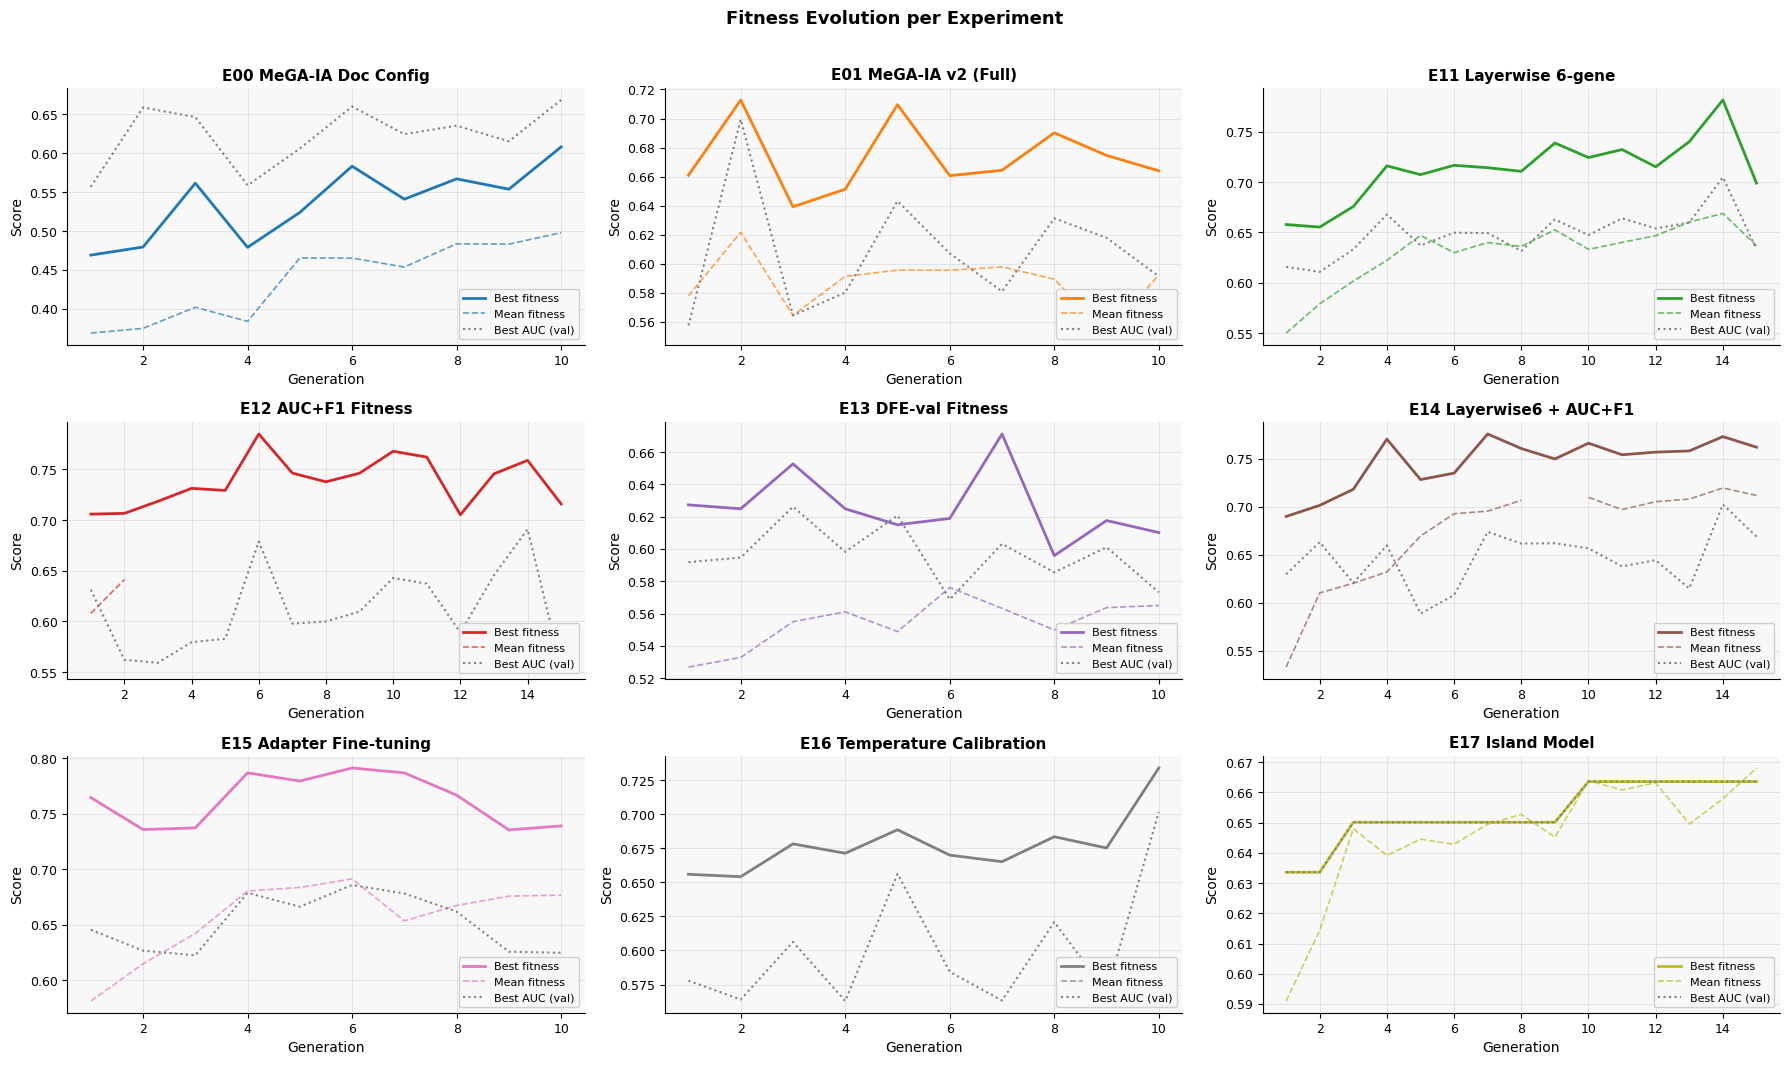

2026-05-11 04:37:00,293 | INFO | Figure 1 saved: fitness curves.
2026-05-11 04:37:00,293 | INFO | Generating Figure 2: Validation metric evolution...


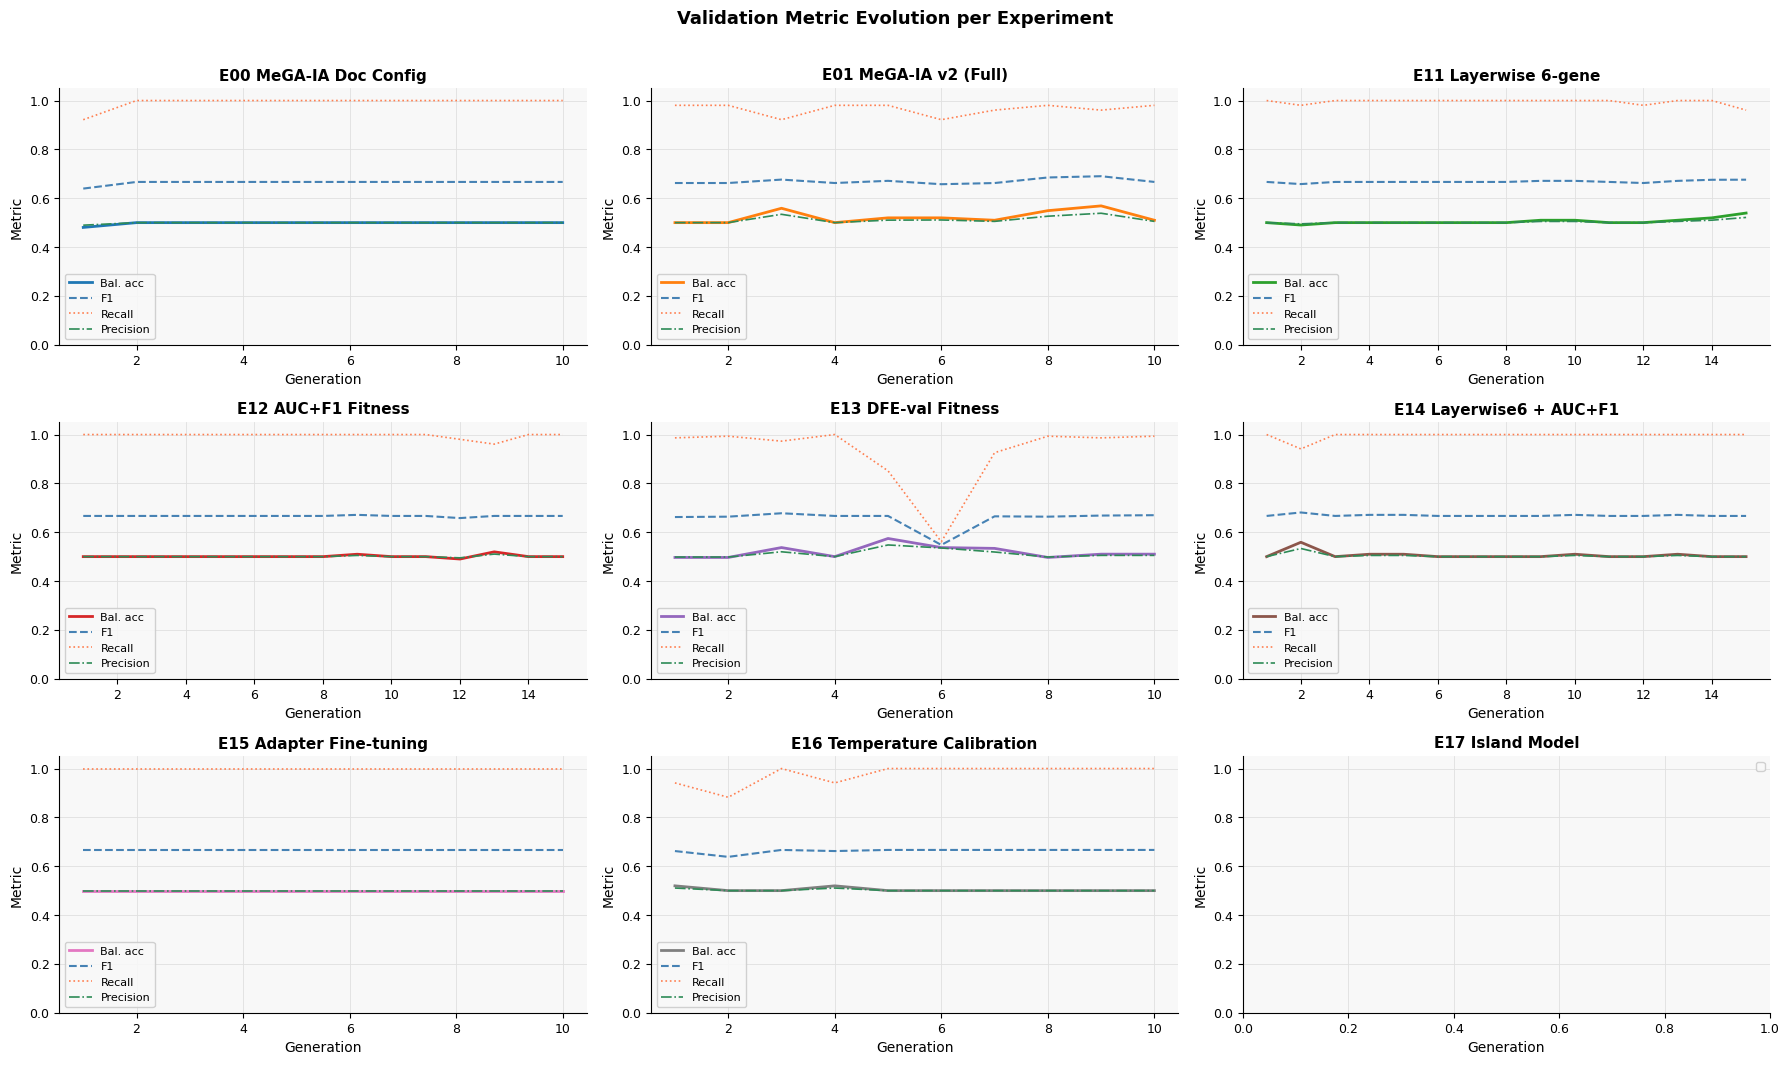

2026-05-11 04:37:03,233 | INFO | Figure 2 saved: val metric curves.
2026-05-11 04:37:03,233 | INFO | Generating Figure 3: Test set comparison bars...


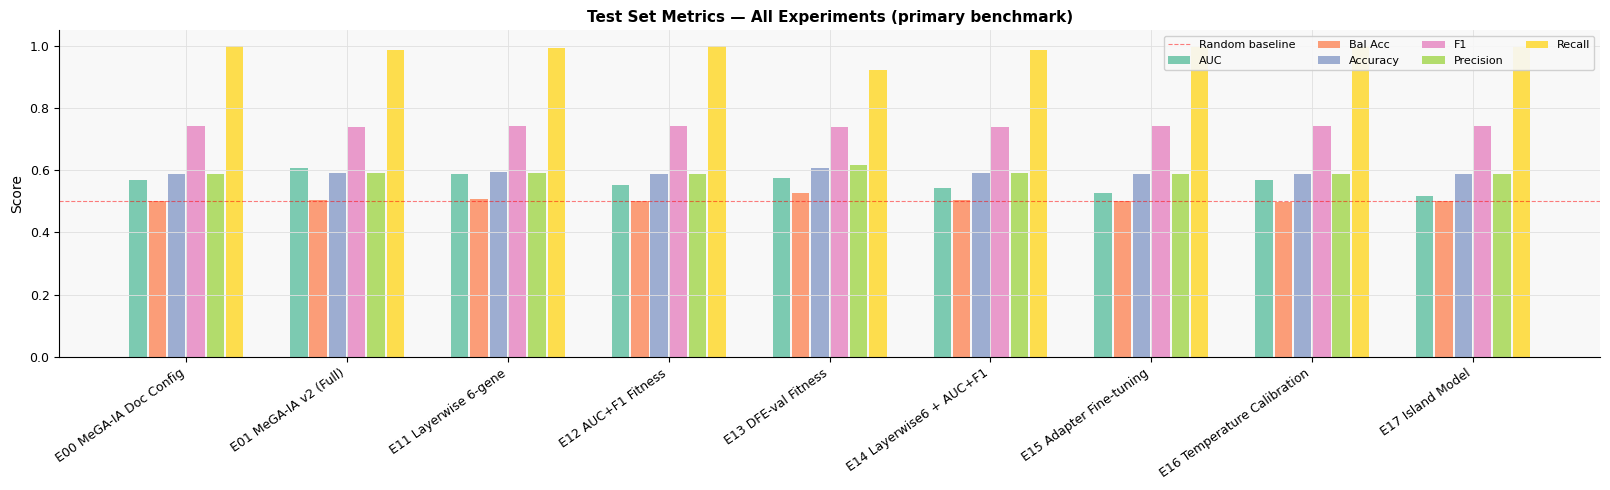

2026-05-11 04:37:03,889 | INFO | Figure 3 saved: test comparison bars.
2026-05-11 04:37:03,890 | INFO | Generating Figure 4: ROC curves...


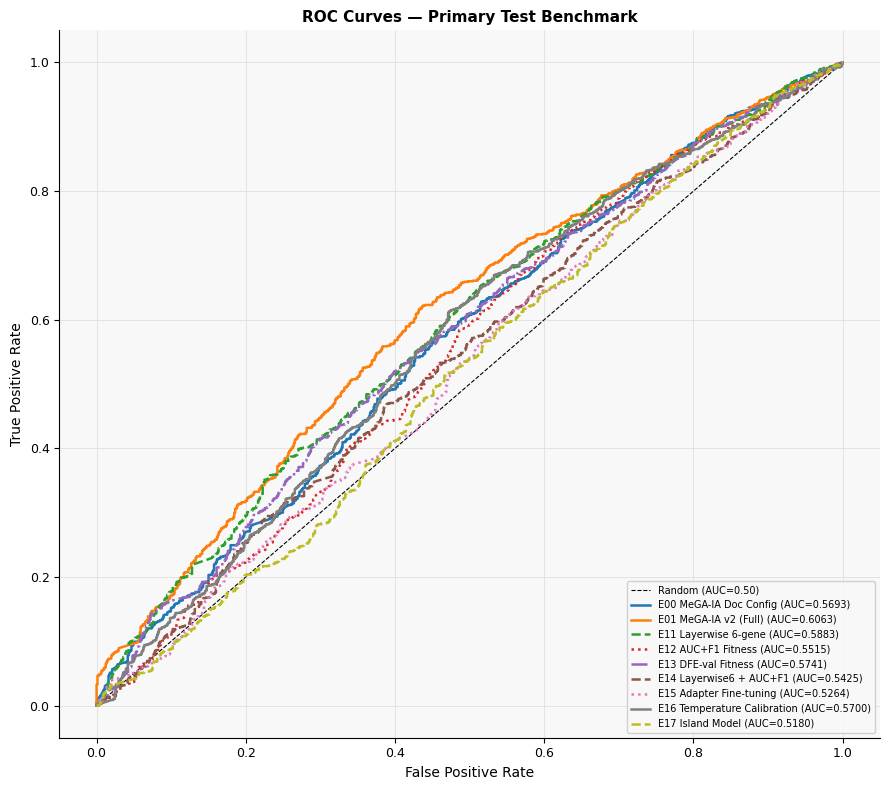

2026-05-11 04:37:04,585 | INFO | Figure 4 saved: ROC curves.
2026-05-11 04:37:04,585 | INFO | Generating Figure 5: Confusion matrices...


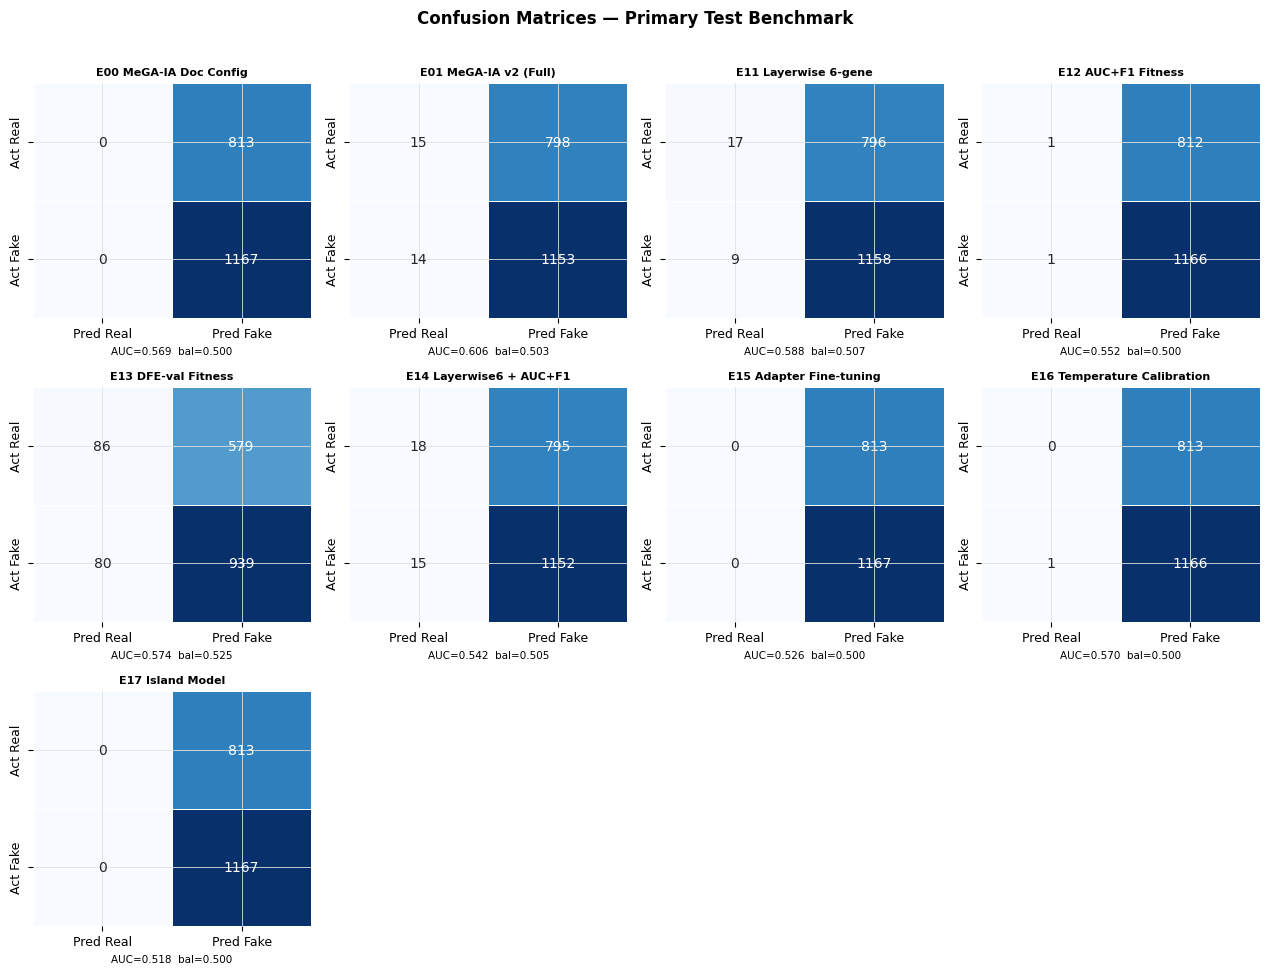

2026-05-11 04:37:08,036 | INFO | Figure 5 saved: confusion matrices.
2026-05-11 04:37:08,037 | INFO | Generating Figure 6: Diversity + mean AUC...


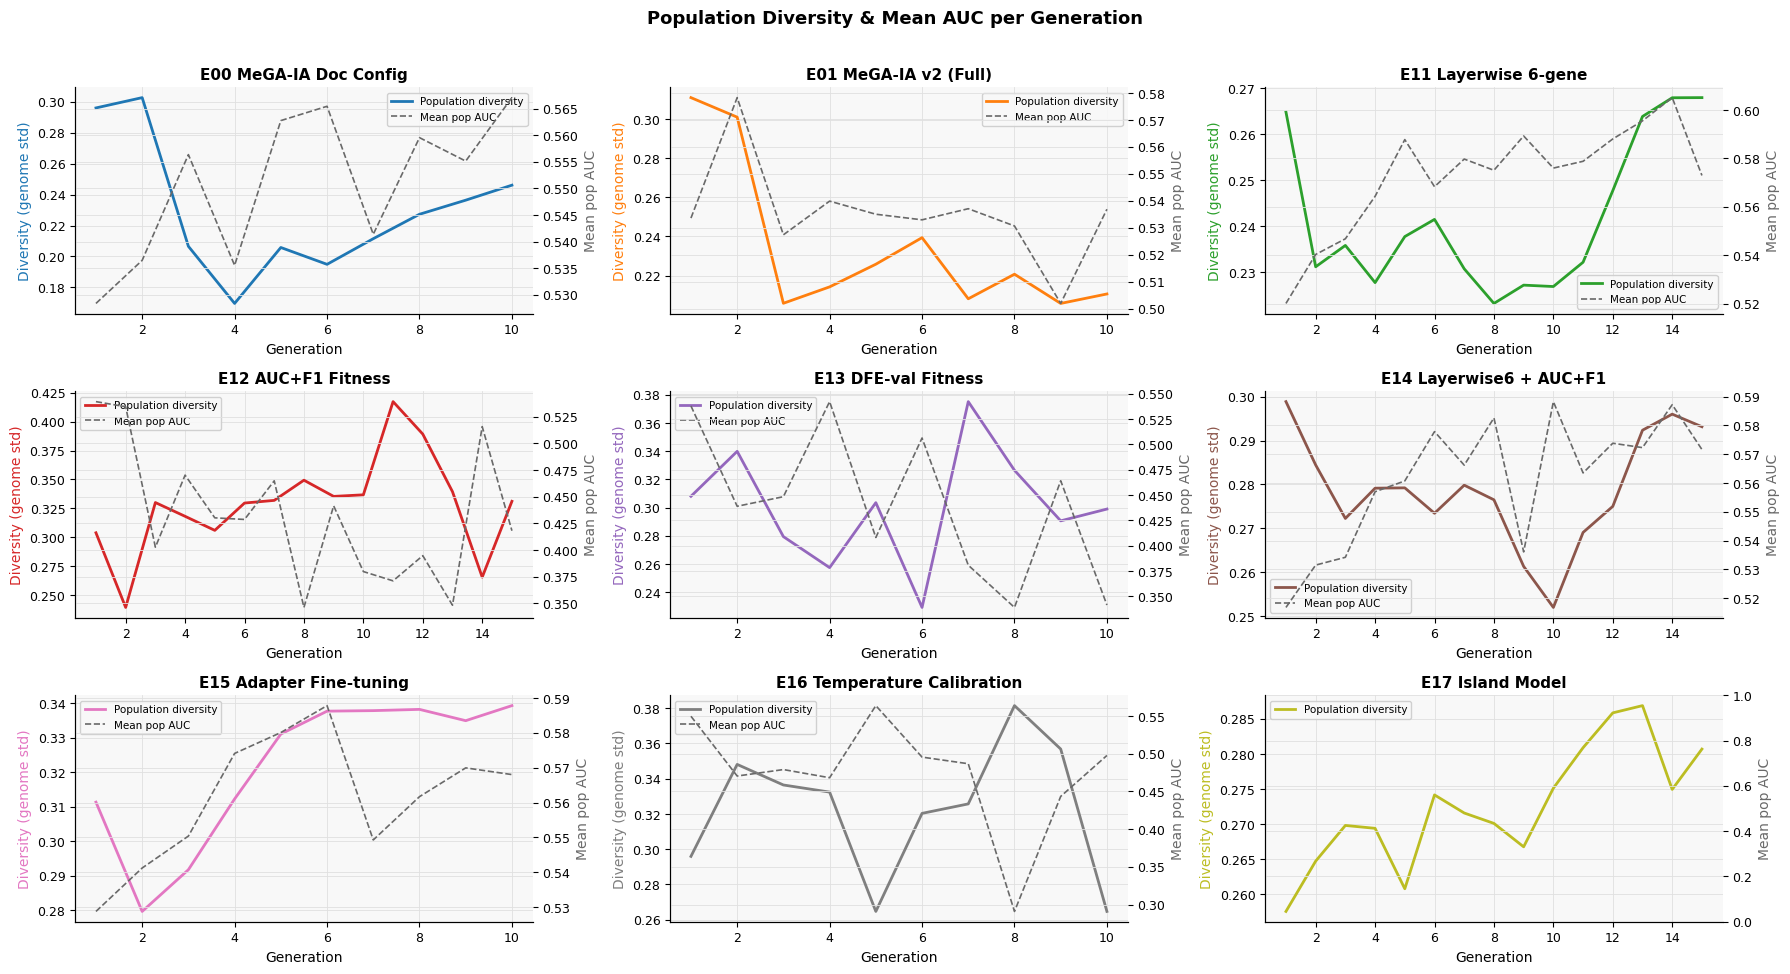

2026-05-11 04:37:12,207 | INFO | Figure 6 saved: diversity curves.


In [ ]:
logger.info('Generating Figure 1: Fitness evolution curves...')
fig_fitness_curves()

logger.info('Generating Figure 2: Validation metric evolution...')
fig_val_metrics_evolution()

logger.info('Generating Figure 3: Test set comparison bars...')
fig_test_comparison()

logger.info('Generating Figure 4: ROC curves...')
fig_roc_curves()

logger.info('Generating Figure 5: Confusion matrices...')
fig_confusion_matrices()

logger.info('Generating Figure 6: Diversity + mean AUC...')
fig_diversity_and_cka()

## Final Summary


In [ ]:
print()
print('=' * 120)
print(f'  FINAL RESULTS SUMMARY — MeGA-IA Experiments vs Primary Test Benchmarks')
print('=' * 120)
print(f'  {"Experiment":<30} {"Group":<22} {"Benchmark":<11} {"AUC":>6} {"BalAcc":>7} {"Acc":>6} '
      f'{"F1":>6} {"Prec":>6} {"Rec":>6}  {"Val AUC":>8}')
print('─' * 120)

def _pri_key(cfg):
    return 'dfe_test' if cfg.get('dfe_val_fitness', False) else 'dfe_full'

ranked = sorted(
    [cfg for cfg in EXPERIMENTS
     if cfg['id'] in all_test_results and _pri_key(cfg) in all_test_results[cfg['id']]],
    key=lambda c: all_test_results[c['id']][_pri_key(c)]['auc'], reverse=True
)

RANK_ICONS = ['🥇', '🥈', '🥉']
for rank, cfg in enumerate(ranked):
    eid  = cfg['id']
    pkey = _pri_key(cfg)
    tm   = all_test_results[eid][pkey]
    vm   = completed_results.get(eid, {}).get('best_val_metrics', {})
    icon = RANK_ICONS[rank] if rank < 3 else f'  {rank+1}.'
    print(f'{icon} {cfg["name"]:<28} {cfg["group"]:<22} {pkey:<11} '
          f'{tm["auc"]:>6.4f} {tm["bal_acc"]:>7.4f} {tm["accuracy"]:>6.4f} '
          f'{tm["f1"]:>6.4f} {tm["precision"]:>6.4f} {tm["recall"]:>6.4f}  '
          f'{vm.get("auc", float("nan")):>8.4f}')

print('─' * 120)

if ranked:
    best = ranked[0]
    bm   = all_test_results[best['id']][_pri_key(best)]
    print()
    print('🏆 BEST EXPERIMENT:', best['name'])
    print(f'   Config : {best["description"]}')
    print(f'   Test   : AUC={bm["auc"]:.4f}  BalAcc={bm["bal_acc"]:.4f}  '
          f'Acc={bm["accuracy"]:.4f}  F1={bm["f1"]:.4f}')
    print(f'   TP={bm["tp"]}  TN={bm["tn"]}  FP={bm["fp"]}  FN={bm["fn"]}')

# ── Per-group best ────────────────────────────────────────────────────────────
print()
print('── PER-GROUP BEST PERFORMANCE ───────────────────────────────────────────')
groups = {}
for cfg in EXPERIMENTS:
    eid  = cfg['id']
    pkey = _pri_key(cfg)
    if eid not in all_test_results or pkey not in all_test_results[eid]:
        continue
    grp     = cfg['group']
    auc_val = all_test_results[eid][pkey]['auc']
    if grp not in groups or auc_val > groups[grp]['auc']:
        groups[grp] = {'name': cfg['name'], 'auc': auc_val,
                       'bal': all_test_results[eid][pkey]['bal_acc'],
                       'f1':  all_test_results[eid][pkey]['f1']}
for grp, info in groups.items():
    print(f'  {grp:<28}  best={info["name"]:<30}  '
          f'AUC={info["auc"]:.4f}  bal={info["bal"]:.4f}  F1={info["f1"]:.4f}')

# ── E15/E16 special results ───────────────────────────────────────────────────
calib_path = os.path.join(str(CKPT_DIR), 'E16_temp_calib_calibration.json')
if os.path.exists(calib_path):
    with open(calib_path) as f:
        cr = json.load(f)
    print()
    print('── E16 TEMPERATURE CALIBRATION RESULTS ─────────────────────────────────')
    print(f'  Before: AUC={cr["before"]["auc"]:.4f}  ECE={cr["before"]["ece"]:.4f}  T=1.000')
    print(f'  After : AUC={cr["after"]["auc"]:.4f}  ECE={cr["after"]["ece"]:.4f}  T={cr["after"]["temp"]:.3f}')

# ── Checkpoint files ──────────────────────────────────────────────────────────
print()
print('── CHECKPOINTED FILES ────────────────────────────────────────────────────')
for f in sorted(os.listdir(str(CKPT_DIR))):
    fpath = os.path.join(str(CKPT_DIR), f)
    print(f'  {f:<60}  {os.path.getsize(fpath)/1e3:>8.1f} KB')

print()
print('=' * 120)
print('  All figures saved to:', str(CKPT_DIR))
print('=' * 120)


  FINAL RESULTS SUMMARY — MeGA-IA Experiments vs Primary Test Benchmarks
  Experiment                     Group                  Benchmark      AUC  BalAcc    Acc     F1   Prec    Rec   Val AUC
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
🥇 E01 MeGA-IA v2 (Full)        v2 — Integrated        dfe_full    0.6063  0.5032 0.5899 0.7396 0.5910 0.9880    0.6993
🥈 E11 Layerwise 6-gene         v3 — Genome            dfe_full    0.5883  0.5066 0.5934 0.7421 0.5926 0.9923    0.7047
🥉 E13 DFE-val Fitness          v3 — Val split         dfe_test    0.5741  0.5254 0.6087 0.7402 0.6186 0.9215    0.6032
  4. E16 Temperature Calibration  v3 — Calibration       dfe_full    0.5700  0.4996 0.5889 0.7413 0.5892 0.9991    0.7017
  5. E00 MeGA-IA Doc Config       v2 — Doc Baseline      dfe_full    0.5693  0.5000 0.5894 0.7417 0.5894 1.0000    0.6682
  6. E12 AUC+F1 Fitness           v3 — Fitness           dfe_full    0.5515  0.5002